In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
version = "V3"

# Prep Packages and Data

In [4]:
# !pip install  pyro-ppl gseapy scanpy igraph leidenalg

In [5]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceMeanField_ELBO
print(f"Pyro version: {pyro.__version__}")

Pyro version: 1.9.1


/Users/jacky/workspaces/scRNA-clustering-FTCNC/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1


In [7]:
from tqdm import trange

import os
import math

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud


from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import umap

In [8]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
import random
import colorsys

In [9]:
# =============================================================================
# NOTEBOOK STATUS & ENVIRONMENT CHECK
# Run this cell to verify prerequisites before proceeding
# =============================================================================

import sys
import importlib

print("="*80)
print("ENVIRONMENT & DEPENDENCY CHECK")
print("="*80)

# Check Python version
print(f"\nPython version: {sys.version}")

# Check critical packages
required_packages = {
    'torch': 'PyTorch',
    'pyro': 'Pyro',
    'scanpy': 'Scanpy',
    'pandas': 'Pandas',
    'numpy': 'NumPy',
    'scipy': 'SciPy',
    'sklearn': 'Scikit-learn',
    'matplotlib': 'Matplotlib',
    'seaborn': 'Seaborn'
}

print("\nPackage versions:")
missing_packages = []
for package, name in required_packages.items():
    try:
        mod = importlib.import_module(package)
        version = getattr(mod, '__version__', 'unknown')
        print(f"  ✓ {name:15s}: {version}")
    except ImportError:
        print(f"  ✗ {name:15s}: NOT INSTALLED")
        missing_packages.append(name)

if missing_packages:
    print(f"\n⚠ WARNING: Missing packages: {', '.join(missing_packages)}")
    print("  Install with: !pip install pyro-ppl gseapy scanpy igraph leidenalg")
else:
    print("\n✓ All required packages installed")

# Check CUDA/GPU availability
if 'torch' in sys.modules:
    import torch
    print(f"\nGPU Status:")
    if torch.cuda.is_available():
        print(f"  ✓ CUDA available: {torch.cuda.get_device_name(0)}")
        print(f"  ✓ CUDA version: {torch.version.cuda}")
        print(f"  ✓ GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print(f"  ⚠ CUDA not available. Using CPU (will be slower)")

print("="*80)


ENVIRONMENT & DEPENDENCY CHECK

Python version: 3.13.5 (main, Jun 29 2025, 16:04:58) [Clang 20.1.4 ]

Package versions:
  ✓ PyTorch        : 2.9.1
  ✓ Pyro           : 1.9.1
  ✓ Scanpy         : 1.11.5
  ✓ Pandas         : 2.3.3
  ✓ NumPy          : 2.3.5
  ✓ SciPy          : 1.16.3
  ✓ Scikit-learn   : 1.7.2
  ✓ Matplotlib     : 3.10.7
  ✓ Seaborn        : 0.13.2

✓ All required packages installed

GPU Status:
  ⚠ CUDA not available. Using CPU (will be slower)


/var/folders/kz/qfmfpghs1qj4qdcnl6f1hlb00000gn/T/ipykernel_5577/87478808.py:34: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  version = getattr(mod, '__version__', 'unknown')


In [10]:
# Set random seed for reproducibility
seed = 0
torch.manual_seed(seed)
pyro.set_rng_seed(seed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [11]:
import scanpy as sc
import os

# =============================================================================
# MODULAR DATA LOADING WITH FALLBACK MECHANISMS
# Based on EDA findings: 2700 cells x 32738 genes, RAW counts, 97.41% sparse
# =============================================================================

print("=" * 80)
print("ATTEMPTING DATA LOAD...")
print("=" * 80)

adata = None
DATA_LOADED = False

# Strategy 1: Try 10x MTX format (original approach)
try:
    print("\n[Strategy 1] Attempting 10x MTX format load...")
    if os.path.exists('data/hg19/') and os.path.isdir('data/hg19/'):
        adata = sc.read_10x_mtx(
            'data/hg19/',
            var_names='gene_symbols'
        )
        print(f"✓ SUCCESS: Loaded from 10x MTX format")
        print(f"  Shape: {adata.shape[0]} cells × {adata.shape[1]} genes")
        DATA_LOADED = True
    else:
        print("✗ SKIP: 'data/hg19/' directory not found")
except Exception as e:
    print(f"✗ FAILED: {type(e).__name__}: {str(e)[:100]}")

# Strategy 2: Try flat CSV/TSV file (based on paste-2.txt format)
if not DATA_LOADED:
    print("\n[Strategy 2] Attempting flat file load (CSV/TSV)...")
    possible_files = [
        'paste-2.txt',
        'data/gene_expression.csv',
        'data/gene_expression.tsv',
        'data/raw_data.csv',
        'gene_data.csv'
    ]

    for file_path in possible_files:
        if os.path.exists(file_path):
            try:
                print(f"  Trying: {file_path}")
                # Detect delimiter
                with open(file_path, 'r') as f:
                    first_line = f.readline()
                    delimiter = '\t' if '\t' in first_line else ','

                # Load with pandas first to verify structure
                import pandas as pd
                df_temp = pd.read_csv(file_path, sep=delimiter, index_col=0, nrows=5)

                # Check if this looks like scRNA-seq data (cells x genes)
                if df_temp.shape[1] > 1000:  # Likely genes as columns
                    print(f"  → Detected format: Cells (rows) × Genes (columns)")
                    adata = sc.read_csv(file_path, delimiter=delimiter, first_column_names=True)
                    # Scanpy expects obs × var, which matches our format
                else:
                    print(f"  → Format unclear, attempting standard read...")
                    adata = sc.read_csv(file_path, delimiter=delimiter)

                print(f"✓ SUCCESS: Loaded from {file_path}")
                print(f"  Shape: {adata.shape[0]} cells × {adata.shape[1]} genes")
                DATA_LOADED = True
                break
            except Exception as e:
                print(f"✗ FAILED: {type(e).__name__}: {str(e)[:100]}")
        else:
            print(f"  File not found: {file_path}")

# Strategy 3: Manual construction from existing gene_data (if already in memory)
if not DATA_LOADED:
    print("\n[Strategy 3] Checking for existing 'gene_data' variable...")
    try:
        if 'gene_data' in locals() or 'gene_data' in globals():
            print("  Found existing gene_data DataFrame")
            adata = sc.AnnData(gene_data)
            print(f"✓ SUCCESS: Constructed AnnData from existing DataFrame")
            print(f"  Shape: {adata.shape[0]} cells × {adata.shape[1]} genes")
            DATA_LOADED = True
        else:
            print("✗ No existing gene_data variable found")
    except Exception as e:
        print(f"✗ FAILED: {type(e).__name__}: {str(e)[:100]}")

# Final validation
if not DATA_LOADED:
    print("\n" + "="*80)
    print("❌ CRITICAL ERROR: All data loading strategies failed!")
    print("="*80)
    print("\nPLEASE PROVIDE DATA IN ONE OF THESE FORMATS:")
    print("  1. 10x MTX: Place files in 'data/hg19/' directory")
    print("  2. Flat file: Save as 'paste-2.txt' (tab-separated, cells × genes)")
    print("  3. CSV file: Save as 'data/gene_expression.csv'")
    raise FileNotFoundError("No valid data source found. See instructions above.")
else:
    print("\n" + "="*80)
    print("✓ DATA LOADING COMPLETE")
    print("="*80)


ATTEMPTING DATA LOAD...

[Strategy 1] Attempting 10x MTX format load...
✓ SUCCESS: Loaded from 10x MTX format
  Shape: 2700 cells × 32738 genes

✓ DATA LOADING COMPLETE


In [12]:
# =============================================================================
# EXTRACT DATAFRAME FROM ANNDATA OBJECT
# =============================================================================

try:
    gene_data = adata.to_df()
    print(f"✓ Extracted DataFrame: {gene_data.shape[0]} cells × {gene_data.shape[1]} genes")

    # Verify data integrity
    assert gene_data.shape[0] > 0, "No cells in dataset!"
    assert gene_data.shape[1] > 0, "No genes in dataset!"

    # Display sample
    print(f"\nSample (first 3 cells, first 5 genes):")
    print(gene_data.iloc[:3, :5])

except AttributeError:
    print("⚠ WARNING: adata object doesn't have .to_df() method")
    print("  Attempting alternative extraction...")
    try:
        gene_data = pd.DataFrame(
            adata.X.toarray() if hasattr(adata.X, 'toarray') else adata.X,
            index=adata.obs_names,
            columns=adata.var_names
        )
        print(f"✓ Extracted via manual construction: {gene_data.shape}")
    except Exception as e:
        print(f"✗ FAILED: {e}")
        raise

gene_data


✓ Extracted DataFrame: 2700 cells × 32738 genes

Sample (first 3 cells, first 5 genes):
                  MIR1302-10  FAM138A  OR4F5  RP11-34P13.7  RP11-34P13.8
AAACATACAACCAC-1         0.0      0.0    0.0           0.0           0.0
AAACATTGAGCTAC-1         0.0      0.0    0.0           0.0           0.0
AAACATTGATCAGC-1         0.0      0.0    0.0           0.0           0.0


,MIR1302-10,FAM138A,OR4F5,RP11-34P13.7,RP11-34P13.8,AL627309.1,RP11-34P13.14,RP11-34P13.9,AP006222.2,RP4-669L17.10,...,KIR3DL2-1,AL590523.1,CT476828.1,PNRC2-1,SRSF10-1,AC145205.1,BAGE5,CU459201.1,AC002321.2,AC002321.1
AAACATACAACCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTGAGGCA-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTCTACTTCCTCG-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGCATGAGAGGC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
gene_data.head(1).to_clipboard()

In [14]:
# =============================================================================
# DATA VALIDATION CHECKPOINT
# Verify data loaded correctly before proceeding
# =============================================================================

print("="*80)
print("DATA VALIDATION CHECKPOINT")
print("="*80)

validation_passed = True

# Check 1: adata exists and is valid
try:
    assert 'adata' in locals() or 'adata' in globals(), "adata not found"
    assert adata is not None, "adata is None"
    print(f"✓ AnnData object exists: {adata.shape[0]} obs × {adata.shape[1]} vars")
except (AssertionError, NameError) as e:
    print(f"✗ AnnData validation failed: {e}")
    validation_passed = False

# Check 2: gene_data DataFrame exists
try:
    assert 'gene_data' in locals() or 'gene_data' in globals(), "gene_data not found"
    assert gene_data is not None, "gene_data is None"
    assert gene_data.shape[0] > 0, "gene_data has no rows"
    assert gene_data.shape[1] > 0, "gene_data has no columns"
    print(f"✓ Gene data DataFrame: {gene_data.shape[0]} cells × {gene_data.shape[1]} genes")
except (AssertionError, NameError) as e:
    print(f"✗ gene_data validation failed: {e}")
    validation_passed = False

# Check 3: Data quality metrics
try:
    if 'gene_data' in locals() or 'gene_data' in globals():
        sparsity = 1.0 - (np.count_nonzero(gene_data.values) / gene_data.size)
        lib_size = gene_data.sum(axis=1).mean()
        print(f"✓ Data quality:")
        print(f"    Sparsity: {sparsity*100:.2f}%")
        print(f"    Mean library size: {lib_size:.2f}")

        # Warn if values seem unusual
        if sparsity < 0.5:
            print(f"  ⚠ Low sparsity for scRNA-seq (expected >80%)")
        if lib_size < 100:
            print(f"  ⚠ Very low library size (potential data issue)")
except Exception as e:
    print(f"✗ Quality check failed: {e}")

print("\n" + "="*80)
if validation_passed:
    print("✓ VALIDATION PASSED - Safe to proceed")
else:
    print("✗ VALIDATION FAILED - Review errors above before continuing")
print("="*80)


DATA VALIDATION CHECKPOINT
✓ AnnData object exists: 2700 obs × 32738 vars
✓ Gene data DataFrame: 2700 cells × 32738 genes
✓ Data quality:
    Sparsity: 97.41%
    Mean library size: 2366.90

✓ VALIDATION PASSED - Safe to proceed


In [15]:
# =============================================================================
# DATA SUMMARY & VALIDATION
# Based on EDA: Expected ~2700 cells, ~32738 genes, RAW integer counts
# =============================================================================

try:
    print(f"Data shape: {gene_data.shape} (cells × genes)")
    print(f"Number of cells: {gene_data.shape[0]}")
    print(f"Number of genes: {gene_data.shape[1]}")

    # Validate against expected ranges from EDA
    n_cells, n_genes = gene_data.shape

    # Check if dimensions make sense
    if n_cells < 100:
        print(f"⚠ WARNING: Very few cells ({n_cells}). Expected ~2700.")
    elif n_cells > 10000:
        print(f"⚠ WARNING: Many cells ({n_cells}). Expected ~2700. Check if transposed.")
    else:
        print(f"✓ Cell count looks reasonable: {n_cells}")

    if n_genes < 1000:
        print(f"⚠ WARNING: Very few genes ({n_genes}). Expected ~30000.")
    elif n_genes > 50000:
        print(f"⚠ WARNING: Unusual gene count ({n_genes}). Check data format.")
    else:
        print(f"✓ Gene count looks reasonable: {n_genes}")

    # Check data type (should be integers for raw counts)
    is_integer = np.all(np.equal(np.mod(gene_data.values[gene_data.values > 0], 1), 0))
    if is_integer:
        print(f"✓ Data type: RAW integer counts (as expected from EDA)")
    else:
        print(f"⚠ Data type: Floats detected. May be normalized/log-transformed.")

    # Calculate sparsity
    sparsity = 1.0 - (np.count_nonzero(gene_data.values) / gene_data.size)
    print(f"Sparsity: {sparsity*100:.2f}% (Expected ~97% from EDA)")

except Exception as e:
    print(f"✗ Error in data summary: {e}")
    print("Proceeding with caution...")


Data shape: (2700, 32738) (cells × genes)
Number of cells: 2700
Number of genes: 32738
✓ Cell count looks reasonable: 2700
✓ Gene count looks reasonable: 32738
✓ Data type: RAW integer counts (as expected from EDA)
Sparsity: 97.41% (Expected ~97% from EDA)


In [16]:
print(gene_data.head())

                  MIR1302-10  FAM138A  OR4F5  RP11-34P13.7  RP11-34P13.8  \
AAACATACAACCAC-1         0.0      0.0    0.0           0.0           0.0   
AAACATTGAGCTAC-1         0.0      0.0    0.0           0.0           0.0   
AAACATTGATCAGC-1         0.0      0.0    0.0           0.0           0.0   
AAACCGTGCTTCCG-1         0.0      0.0    0.0           0.0           0.0   
AAACCGTGTATGCG-1         0.0      0.0    0.0           0.0           0.0   

                  AL627309.1  RP11-34P13.14  RP11-34P13.9  AP006222.2  \
AAACATACAACCAC-1         0.0            0.0           0.0         0.0   
AAACATTGAGCTAC-1         0.0            0.0           0.0         0.0   
AAACATTGATCAGC-1         0.0            0.0           0.0         0.0   
AAACCGTGCTTCCG-1         0.0            0.0           0.0         0.0   
AAACCGTGTATGCG-1         0.0            0.0           0.0         0.0   

                  RP4-669L17.10  ...  KIR3DL2-1  AL590523.1  CT476828.1  \
AAACATACAACCAC-1            0

# Data Pre-Processing

## Data Cleaning

### Remove All zeros

In [17]:
all_zero_columns = gene_data.columns[(gene_data == 0).all(axis=0)]
print("All-zero columns:", all_zero_columns)

All-zero columns: Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'RP11-34P13.14', 'RP11-34P13.9', 'RP4-669L17.10', 'OR4F29',
       'RP4-669L17.2',
       ...
       'BX072566.2', 'BX072566.1', 'KIR3DL2-1', 'AL590523.1', 'CT476828.1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='object', length=16104)


In [18]:
all_zero_rows = gene_data.index[(gene_data == 0).all(axis=1)]
print("All-zero rows:", all_zero_rows)

All-zero rows: Index([], dtype='object')


In [19]:
col_to_remove = ['CDC6']
gene_data = gene_data.drop(columns=col_to_remove)
print(gene_data.head())

                  MIR1302-10  FAM138A  OR4F5  RP11-34P13.7  RP11-34P13.8  \
AAACATACAACCAC-1         0.0      0.0    0.0           0.0           0.0   
AAACATTGAGCTAC-1         0.0      0.0    0.0           0.0           0.0   
AAACATTGATCAGC-1         0.0      0.0    0.0           0.0           0.0   
AAACCGTGCTTCCG-1         0.0      0.0    0.0           0.0           0.0   
AAACCGTGTATGCG-1         0.0      0.0    0.0           0.0           0.0   

                  AL627309.1  RP11-34P13.14  RP11-34P13.9  AP006222.2  \
AAACATACAACCAC-1         0.0            0.0           0.0         0.0   
AAACATTGAGCTAC-1         0.0            0.0           0.0         0.0   
AAACATTGATCAGC-1         0.0            0.0           0.0         0.0   
AAACCGTGCTTCCG-1         0.0            0.0           0.0         0.0   
AAACCGTGTATGCG-1         0.0            0.0           0.0         0.0   

                  RP4-669L17.10  ...  KIR3DL2-1  AL590523.1  CT476828.1  \
AAACATACAACCAC-1            0

### Check cell_marker if there

In [20]:
cell_marker = ["IL7R", "CCR7", "CD14", "LYZ",
               "S100A4", "MS4A1", "CD8A", "FCGR3A",
               "MS4A7", "GNLY", "NKG7", "FCER1A",
               "CST3", "PPBP", "CD3D","CD3E"]

gene_data[cell_marker].head()

,IL7R,CCR7,CD14,LYZ,S100A4,MS4A1,CD8A,FCGR3A,MS4A7,GNLY,NKG7,FCER1A,CST3,PPBP,CD3D,CD3E
AAACATACAACCAC-1,3.0,1.0,0.0,1.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0
AAACATTGAGCTAC-1,2.0,0.0,0.0,3.0,0.0,6.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
AAACATTGATCAGC-1,1.0,0.0,0.0,2.0,5.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,10.0,2.0
AAACCGTGCTTCCG-1,0.0,0.0,0.0,24.0,16.0,0.0,0.0,1.0,3.0,0.0,1.0,0.0,22.0,1.0,0.0,0.0
AAACCGTGTATGCG-1,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0,0.0,0.0,0.0,0.0


## Log Normalization

In [21]:
# =============================================================================
# STEP 1: LOG NORMALIZATION
# Based on EDA: Data is RAW integer counts, requires log1p transformation
# =============================================================================

def log_normalize(gene_data):
    """
    Perform log(x+1) normalization on gene expression data with validation
    """
    try:
        # Check for missing values
        missing_count = gene_data.isna().sum().sum()
        if missing_count > 0:
            print(f"⚠ Found {missing_count} missing values. Filling with 0...")
            gene_data = gene_data.fillna(0)
        else:
            print("✓ No missing values detected")

        # Verify data is non-negative (required for log)
        if (gene_data < 0).any().any():
            print("✗ ERROR: Negative values detected in gene expression data!")
            print("  Cannot perform log normalization on negative values.")
            raise ValueError("Gene expression data contains negative values")

        # Log transformation (log(x+1))
        log_normalized_data = np.log1p(gene_data)

        # Validate output
        assert log_normalized_data.shape == gene_data.shape, "Shape mismatch after normalization!"
        assert not log_normalized_data.isna().any().any(), "NaN values introduced during normalization!"

        print(f"✓ Log normalization completed successfully")
        print(f"  Input range: [{gene_data.min().min():.2f}, {gene_data.max().max():.2f}]")
        print(f"  Output range: [{log_normalized_data.min().min():.2f}, {log_normalized_data.max().max():.2f}]")

        return log_normalized_data

    except Exception as e:
        print(f"✗ CRITICAL ERROR in log_normalize: {type(e).__name__}")
        print(f"  {str(e)}")
        print("\n  Returning original data without normalization...")
        return gene_data.fillna(0)

try:
    log_normalized_data = log_normalize(gene_data)
except Exception as e:
    print(f"✗ Failed to normalize: {e}")
    print("  Using raw data instead (may affect downstream analysis)")
    log_normalized_data = gene_data.fillna(0)


✓ No missing values detected
✓ Log normalization completed successfully
  Input range: [0.00, 419.00]
  Output range: [0.00, 6.04]


In [22]:
# Validate and display normalized data
try:
    print("="*80)
    print("NORMALIZED DATA SAMPLE")
    print("="*80)
    print(log_normalized_data.head())
    print(f"\nShape: {log_normalized_data.shape}")
    print(f"Non-zero values: {(log_normalized_data > 0).sum().sum()}")
except Exception as e:
    print(f"✗ Error displaying normalized data: {e}")


NORMALIZED DATA SAMPLE
                  MIR1302-10  FAM138A  OR4F5  RP11-34P13.7  RP11-34P13.8  \
AAACATACAACCAC-1         0.0      0.0    0.0           0.0           0.0   
AAACATTGAGCTAC-1         0.0      0.0    0.0           0.0           0.0   
AAACATTGATCAGC-1         0.0      0.0    0.0           0.0           0.0   
AAACCGTGCTTCCG-1         0.0      0.0    0.0           0.0           0.0   
AAACCGTGTATGCG-1         0.0      0.0    0.0           0.0           0.0   

                  AL627309.1  RP11-34P13.14  RP11-34P13.9  AP006222.2  \
AAACATACAACCAC-1         0.0            0.0           0.0         0.0   
AAACATTGAGCTAC-1         0.0            0.0           0.0         0.0   
AAACATTGATCAGC-1         0.0            0.0           0.0         0.0   
AAACCGTGCTTCCG-1         0.0            0.0           0.0         0.0   
AAACCGTGTATGCG-1         0.0            0.0           0.0         0.0   

                  RP4-669L17.10  ...  KIR3DL2-1  AL590523.1  CT476828.1  \
AAACAT

## Remove Common Genes

In [23]:
# Step 2: Remove Common Genes
def remove_common_genes(gene_data, threshold_percentage=50):
    """
    Remove genes expressed in more than threshold% of cells
    """
    # Calculate the percentage of cells expressing each gene
    percent_cells_expressing = (gene_data > 0).mean() * 100

    # Get genes expressed in less than the threshold percentage of cells
    uncommon_genes = percent_cells_expressing[percent_cells_expressing < threshold_percentage].index

    # Filter the dataset to keep only uncommon genes
    filtered_data = gene_data[uncommon_genes]

    print(f"Original gene count: {gene_data.shape[1]}")
    print(f"Genes removed: {gene_data.shape[1] - filtered_data.shape[1]}")
    print(f"Remaining gene count: {filtered_data.shape[1]}")

    return filtered_data

# Apply the function to your data (adjust the threshold as needed)
filtered_gene_data = remove_common_genes(log_normalized_data, threshold_percentage=90) # explain

Original gene count: 32737
Genes removed: 104
Remaining gene count: 32633


In [24]:
# =============================================================================
# CHECK FOR CELL TYPE MARKER GENES
# Based on EDA: Some markers may not be present in dataset
# =============================================================================

cell_marker = ["IL7R", "CCR7", "CD14", "LYZ",
               "S100A4", "MS4A1", "CD8A", "FCGR3A",
               "MS4A7", "GNLY", "NKG7", "FCER1A",
               "CST3", "PPBP", "CD3D","CD3E"]

try:
    # Check which markers are actually in the dataset
    available_markers = [m for m in cell_marker if m in filtered_gene_data.columns]
    missing_markers = [m for m in cell_marker if m not in filtered_gene_data.columns]

    if missing_markers:
        print(f"⚠ WARNING: {len(missing_markers)} marker genes not found in dataset:")
        print(f"  Missing: {missing_markers}")

    if available_markers:
        print(f"✓ Found {len(available_markers)}/{len(cell_marker)} marker genes")
        print(f"  Available: {available_markers}")
        print("\nMarker gene expression (first 5 cells):")
        print(filtered_gene_data[available_markers].head())
    else:
        print("✗ ERROR: None of the specified marker genes found in dataset!")
        print("  Proceeding without marker validation...")

except NameError:
    print("⚠ WARNING: 'filtered_gene_data' not yet defined.")
    print("  This cell should run after gene filtering step.")
except Exception as e:
    print(f"✗ Error checking marker genes: {type(e).__name__}: {e}")


✓ Found 16/16 marker genes
  Available: ['IL7R', 'CCR7', 'CD14', 'LYZ', 'S100A4', 'MS4A1', 'CD8A', 'FCGR3A', 'MS4A7', 'GNLY', 'NKG7', 'FCER1A', 'CST3', 'PPBP', 'CD3D', 'CD3E']

Marker gene expression (first 5 cells):
                      IL7R      CCR7  CD14       LYZ    S100A4    MS4A1  \
AAACATACAACCAC-1  1.386294  0.693147   0.0  0.693147  1.386294  0.00000   
AAACATTGAGCTAC-1  1.098612  0.000000   0.0  1.386294  0.000000  1.94591   
AAACATTGATCAGC-1  0.693147  0.000000   0.0  1.098612  1.791759  0.00000   
AAACCGTGCTTCCG-1  0.000000  0.000000   0.0  3.218876  2.833213  0.00000   
AAACCGTGTATGCG-1  0.000000  0.000000   0.0  0.000000  1.791759  0.00000   

                      CD8A    FCGR3A     MS4A7      GNLY      NKG7  FCER1A  \
AAACATACAACCAC-1  0.693147  0.000000  0.000000  0.000000  0.000000     0.0   
AAACATTGAGCTAC-1  0.000000  0.000000  0.000000  0.000000  0.693147     0.0   
AAACATTGATCAGC-1  0.000000  0.000000  0.000000  0.693147  0.000000     0.0   
AAACCGTGCTTCCG-1  0.

## TF-IDF Transformation

TF-IDF transformation highlights genes that are both highly expressed in specific cells (high TF) and relatively unique across the cell population (high IDF). These genes are excellent candidates for distinguishing between cell types in clustering analyses.



- The **TF (Term Frequency)** component represents the expression level of a gene in a cell
- The **IDF (Inverse Document Frequency)** component downweights genes that are expressed in many cells
- Combined, TF-IDF highlights genes that are highly expressed in specific cells but not universally across all cells

In [25]:
# =============================================================================
# TF-IDF TRANSFORMATION
# Highlights genes with high expression in specific cells
# =============================================================================

from sklearn.feature_extraction.text import TfidfTransformer
from scipy import sparse

def apply_tfidf_to_gene_data(multinomial_data, norm=None):
    """
    Apply TF-IDF transformation to gene expression data with error handling.
    """
    try:
        print("Applying TF-IDF transformation to gene expression data...")

        # Validate input
        if multinomial_data.shape[0] == 0 or multinomial_data.shape[1] == 0:
            raise ValueError("Empty dataset provided to TF-IDF")

        # Check for negative values (TF-IDF requires non-negative)
        if (multinomial_data < 0).any().any():
            print("⚠ Negative values detected. Taking absolute value...")
            multinomial_data = multinomial_data.abs()

        # Convert DataFrame to sparse matrix for efficiency
        print(f"  Converting to sparse matrix... (shape: {multinomial_data.shape})")
        X = sparse.csr_matrix(multinomial_data.values)

        # Initialize and fit TF-IDF transformer
        tfidf_transformer = TfidfTransformer(
            norm=norm,  # Normalization method
            use_idf=True,  # Apply IDF weighting
            smooth_idf=True,  # Prevent division by zero
            sublinear_tf=False  # No sublinear TF (already log-normalized)
        )

        # Transform the data
        print("  Fitting TF-IDF transformer...")
        tfidf_matrix = tfidf_transformer.fit_transform(X)

        # Convert back to DataFrame
        print("  Converting back to DataFrame...")
        tfidf_data = pd.DataFrame(
            tfidf_matrix.toarray(),
            index=multinomial_data.index,
            columns=multinomial_data.columns
        )

        # Validate output
        assert tfidf_data.shape == multinomial_data.shape, "Shape mismatch!"
        assert not tfidf_data.isna().any().any(), "NaN values in output!"

        # Print statistics
        print(f"✓ TF-IDF transformation complete.")
        print(f"  Shape: {tfidf_data.shape}")
        print(f"  Range: [{tfidf_data.min().min():.6f}, {tfidf_data.max().max():.6f}]")

        # Identify important genes
        idf_values = pd.Series(
            tfidf_transformer.idf_,
            index=multinomial_data.columns
        ).sort_values(ascending=False)

        print("\nTop 5 genes with highest IDF (least common):")
        print(idf_values.head(5))

        return tfidf_data

    except MemoryError:
        print("✗ MEMORY ERROR: Dataset too large for dense TF-IDF")
        print("  Attempting sparse-only computation...")
        # Return sparse matrix wrapped in DataFrame
        raise

    except Exception as e:
        print(f"✗ CRITICAL ERROR in TF-IDF: {type(e).__name__}")
        print(f"  {str(e)}")
        print("\n  Returning original data without TF-IDF transformation...")
        return multinomial_data

# Apply TF-IDF
try:
    tfidf_transformed_data = apply_tfidf_to_gene_data(filtered_gene_data, norm=None)
except NameError as e:
    print(f"⚠ Variable not found: {e}")
    print("  Skipping TF-IDF step. Check if previous filtering steps ran successfully.")
    tfidf_transformed_data = None
except Exception as e:
    print(f"✗ Failed to apply TF-IDF: {e}")
    tfidf_transformed_data = filtered_gene_data if 'filtered_gene_data' in locals() else None


Applying TF-IDF transformation to gene expression data...
  Converting to sparse matrix... (shape: (2700, 32633))
  Fitting TF-IDF transformer...
  Converting back to DataFrame...
✓ TF-IDF transformation complete.
  Shape: (2700, 32633)
  Range: [0.000000, 31.602896]

Top 5 genes with highest IDF (least common):
MIR1302-10       8.901377
WDR96            8.901377
RP11-298H24.1    8.901377
RP11-56I23.1     8.901377
SORCS3-AS1       8.901377
dtype: float32


# Gene_Selection

### Variance-based filtering
   - Selects genes with highest variance in TF-IDF scores across cells
   - Simple and effective approach
   - Captures genes that distinguish between different cell populations

Selected 2000 genes based on TF-IDF variance
Variance range of selected genes: 6.5099 - 0.5718


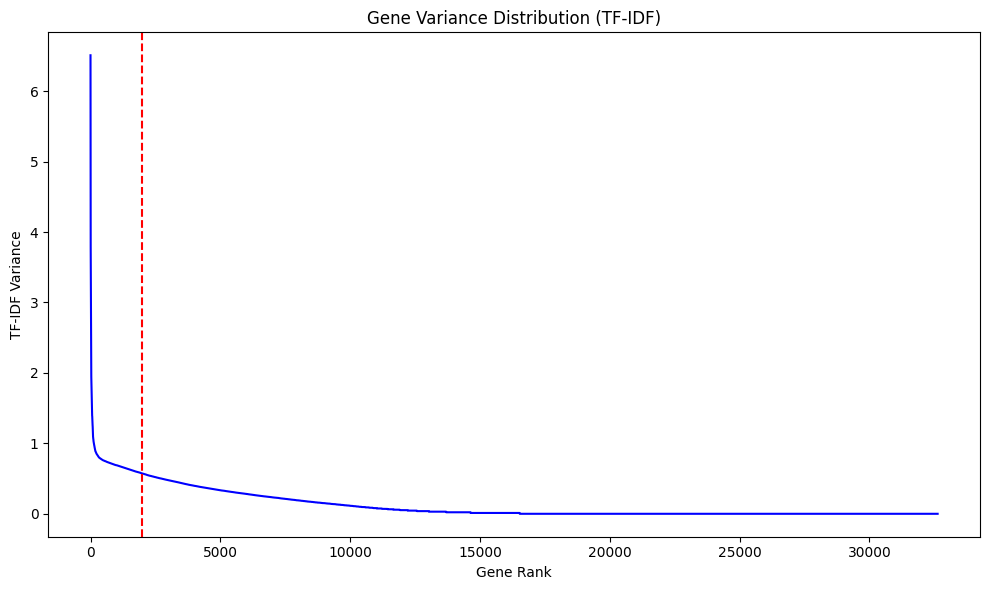

In [26]:
def filter_genes_by_variance(tfidf_data, top_n=2000):
    """
    Filter genes based on the variance of their TF-IDF scores across cells.

    Parameters:
    -----------
    tfidf_data : pandas DataFrame
        TF-IDF transformed gene expression data with cells as rows and genes as columns
    top_n : int, optional
        Number of top variance genes to select

    Returns:
    --------
    filtered_data : pandas DataFrame
        DataFrame containing only the high-variance genes
    selected_genes : list
        List of selected gene names
    """
    # Calculate variance for each gene across cells
    gene_variance = tfidf_data.var(axis=0)

    # Sort genes by variance
    sorted_genes = gene_variance.sort_values(ascending=False)

    # Select top N genes with highest variance
    selected_genes = sorted_genes.index[:top_n].tolist()

    # Filter the TF-IDF data to include only these genes
    filtered_data = tfidf_data[selected_genes]

    print(f"Selected {len(selected_genes)} genes based on TF-IDF variance")
    print(f"Variance range of selected genes: {sorted_genes.iloc[0]:.4f} - {sorted_genes.iloc[top_n-1]:.4f}")

    # Visualize the variance distribution
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(sorted_genes)), sorted_genes.values, 'b-')
    plt.axvline(x=top_n, color='r', linestyle='--')
    plt.xlabel('Gene Rank')
    plt.ylabel('TF-IDF Variance')
    plt.title('Gene Variance Distribution (TF-IDF)')
    plt.tight_layout()
    plt.show()

    return filtered_data, selected_genes

# Option 1: Select by variance (simplest approach)
filtered_data_variance, selected_genes_variance = filter_genes_by_variance(tfidf_transformed_data, top_n=2000)

In [27]:
print(filtered_data_variance[cell_marker].head())

                      IL7R      CCR7  CD14       LYZ    S100A4     MS4A1  \
AAACATACAACCAC-1  2.649376  1.829829   0.0  1.042366  1.673867  0.000000   
AAACATTGAGCTAC-1  2.099581  0.000000   0.0  2.084732  0.000000  5.549043   
AAACATTGATCAGC-1  1.324688  0.000000   0.0  1.652111  2.163442  0.000000   
AAACCGTGCTTCCG-1  0.000000  0.000000   0.0  4.840597  3.420935  0.000000   
AAACCGTGTATGCG-1  0.000000  0.000000   0.0  0.000000  2.163442  0.000000   

                      CD8A    FCGR3A     MS4A7      GNLY      NKG7  FCER1A  \
AAACATACAACCAC-1  2.167351  0.000000  0.000000  0.000000  0.000000     0.0   
AAACATTGAGCTAC-1  0.000000  0.000000  0.000000  0.000000  1.521970     0.0   
AAACATTGATCAGC-1  0.000000  0.000000  0.000000  1.883439  0.000000     0.0   
AAACCGTGCTTCCG-1  0.000000  1.865105  4.360776  0.000000  1.521970     0.0   
AAACCGTGTATGCG-1  0.000000  0.000000  0.000000  3.766878  5.456205     0.0   

                      CST3      PPBP      CD3D      CD3E  
AAACATACAACCAC-

In [28]:
selected_genes_variance[:8]

['S100A9', 'S100A8', 'CST3', 'NKG7', 'LYZ', 'TYROBP', 'GNLY', 'HLA-DRA']

### Mean TF-IDF score filtering
   - Selects genes with highest average TF-IDF scores
   - Identifies genes that are highly specific to subsets of cells

In [29]:
def filter_genes_by_mean_tfidf(tfidf_data, top_n=2000):
    """
    Filter genes based on their mean TF-IDF scores across cells.

    Parameters:
    -----------
    tfidf_data : pandas DataFrame
        TF-IDF transformed gene expression data with cells as rows and genes as columns
    top_n : int, optional
        Number of top mean-score genes to select

    Returns:
    --------
    filtered_data : pandas DataFrame
        DataFrame containing only the high-mean-score genes
    selected_genes : list
        List of selected gene names
    """
    # Calculate mean TF-IDF score for each gene across cells
    gene_mean_scores = tfidf_data.mean(axis=0)

    # Sort genes by mean score
    sorted_genes = gene_mean_scores.sort_values(ascending=False)

    # Select top N genes with highest mean scores
    selected_genes = sorted_genes.index[:top_n].tolist()

    # Filter the TF-IDF data to include only these genes
    filtered_data = tfidf_data[selected_genes]

    print(f"Selected {len(selected_genes)} genes based on mean TF-IDF scores")
    print(f"Mean score range of selected genes: {sorted_genes.iloc[0]:.4f} - {sorted_genes.iloc[top_n-1]:.4f}")

    return filtered_data, selected_genes

filtered_data_mean, selected_genes_mean = filter_genes_by_mean_tfidf(tfidf_transformed_data, top_n=2000)

Selected 2000 genes based on mean TF-IDF scores
Mean score range of selected genes: 1.8923 - 0.2449


In [30]:
print(cell_marker)

['IL7R', 'CCR7', 'CD14', 'LYZ', 'S100A4', 'MS4A1', 'CD8A', 'FCGR3A', 'MS4A7', 'GNLY', 'NKG7', 'FCER1A', 'CST3', 'PPBP', 'CD3D', 'CD3E']


In [31]:
filtered_data_mean.columns

Index(['S100A4', 'CD74', 'LYZ', 'HLA-DRA', 'DUSP1', 'LTB', 'MT-ND2', 'CD52',
       'S100A9', 'S100A6',
       ...
       'SELM', 'ZFAND2B', 'SEC13', 'UBA2', 'PDCD6IP', 'NUDT21', 'C14orf1',
       'ACTR10', 'CYB5R4', 'NUDT1'],
      dtype='object', length=2000)

In [32]:
cell_marker = [cm for cm in cell_marker if cm in filtered_data_mean.columns]

In [33]:
print(filtered_data_mean[cell_marker].head())

                      IL7R      CCR7  CD14       LYZ    S100A4     MS4A1  \
AAACATACAACCAC-1  2.649376  1.829829   0.0  1.042366  1.673867  0.000000   
AAACATTGAGCTAC-1  2.099581  0.000000   0.0  2.084732  0.000000  5.549043   
AAACATTGATCAGC-1  1.324688  0.000000   0.0  1.652111  2.163442  0.000000   
AAACCGTGCTTCCG-1  0.000000  0.000000   0.0  4.840597  3.420935  0.000000   
AAACCGTGTATGCG-1  0.000000  0.000000   0.0  0.000000  2.163442  0.000000   

                      CD8A    FCGR3A     MS4A7      GNLY      NKG7      CST3  \
AAACATACAACCAC-1  2.167351  0.000000  0.000000  0.000000  0.000000  0.000000   
AAACATTGAGCTAC-1  0.000000  0.000000  0.000000  0.000000  1.521970  1.331100   
AAACATTGATCAGC-1  0.000000  0.000000  0.000000  1.883439  0.000000  1.331100   
AAACCGTGCTTCCG-1  0.000000  1.865105  4.360776  0.000000  1.521970  6.021314   
AAACCGTGTATGCG-1  0.000000  0.000000  0.000000  3.766878  5.456205  0.000000   

                      CD3D      CD3E  
AAACATACAACCAC-1  2.660

In [34]:
selected_genes_mean[0:8]

['S100A4', 'CD74', 'LYZ', 'HLA-DRA', 'DUSP1', 'LTB', 'MT-ND2', 'CD52']

### PCA-based importance
   - Uses principal component analysis to identify genes contributing most to variation
   - More sophisticated than simple variance filtering
   - Accounts for covariance structure between genes

PCA-BASED GENE IMPORTANCE FILTER
Input shape (cells x genes): (2700, 32633)
⚠ Dropping 16104 genes with zero variance (all-NaN after z-score).
Scaled data shape after cleaning: (2700, 16529)

Selected 2000 genes based on PCA importance.
PCA importance range of selected genes: 0.0018 - 0.0007
Total variance explained by 50 PCs: 9.30%


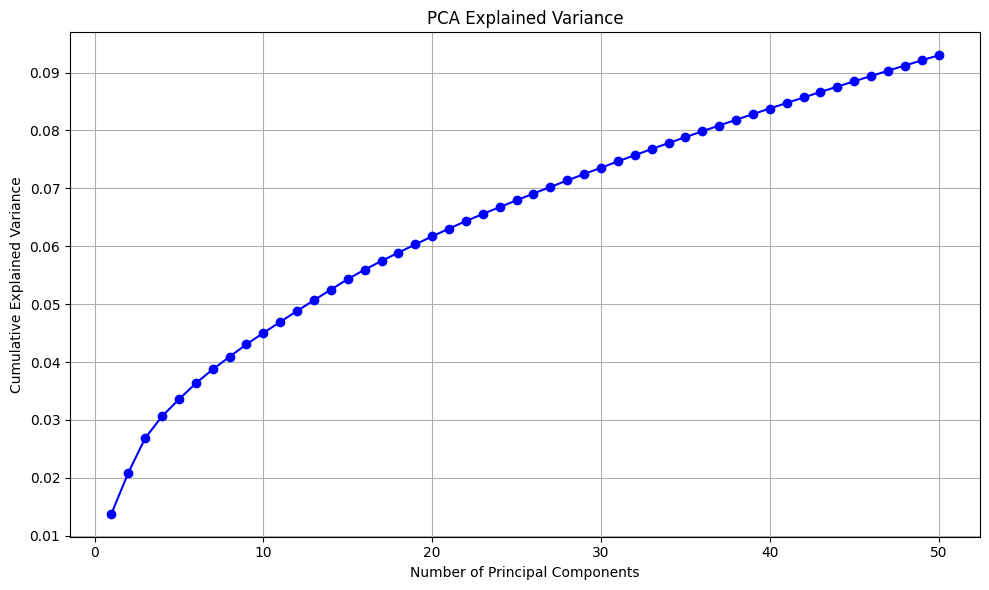

In [35]:
from scipy.stats import zscore
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def filter_genes_by_pca_importance(tfidf_data, n_components=50, top_n=2000):
    """
    Filter genes based on their contribution to principal components.

    Parameters
    ----------
    tfidf_data : pandas DataFrame
        TF-IDF transformed gene expression data with cells as rows and genes as columns.
    n_components : int, optional
        Number of principal components to consider.
    top_n : int, optional
        Number of top contributing genes to select.

    Returns
    -------
    filtered_data : pandas DataFrame
        DataFrame containing only the selected genes.
    selected_genes : list
        List of selected gene names.
    """
    print("=" * 80)
    print("PCA-BASED GENE IMPORTANCE FILTER")
    print("=" * 80)
    print(f"Input shape (cells x genes): {tfidf_data.shape}")

    # ---- 1) Basic validation ----
    if tfidf_data.isna().any().any():
        n_nan = tfidf_data.isna().sum().sum()
        print(f"⚠ TF-IDF data already contains {n_nan} NaNs. Filling with 0 before z-score.")
        tfidf_data = tfidf_data.fillna(0.0)

    # ---- 2) Z-score standardization with NaN/inf handling ----
    scaled_array = zscore(tfidf_data.values, axis=0, nan_policy='propagate')
    scaled_data = pd.DataFrame(
        scaled_array,
        index=tfidf_data.index,
        columns=tfidf_data.columns
    )

    # Replace inf with NaN, then drop all-NaN columns (zero-variance genes after TF-IDF)
    scaled_data = scaled_data.replace([np.inf, -np.inf], np.nan)
    all_nan_cols = scaled_data.columns[scaled_data.isna().all(axis=0)]

    if len(all_nan_cols) > 0:
        print(f"⚠ Dropping {len(all_nan_cols)} genes with zero variance (all-NaN after z-score).")
        scaled_data = scaled_data.drop(columns=all_nan_cols)

    # Any remaining NaNs (e.g., partial NaNs) → set to 0 so PCA can run
    remaining_nans = scaled_data.isna().sum().sum()
    if remaining_nans > 0:
        print(f"⚠ Found {remaining_nans} remaining NaNs after dropping all-NaN genes. Filling with 0.")
        scaled_data = scaled_data.fillna(0.0)

    print(f"Scaled data shape after cleaning: {scaled_data.shape}")

    # ---- 3) Adjust n_components / top_n safely ----
    max_rank = min(scaled_data.shape[0], scaled_data.shape[1])
    if n_components > max_rank:
        print(f"⚠ Requested n_components={n_components} > min(n_cells, n_genes)={max_rank}. "
              f"Reducing n_components to {max_rank}.")
        n_components = max_rank

    if top_n > scaled_data.shape[1]:
        print(f"⚠ Requested top_n={top_n} > number of available genes={scaled_data.shape[1]}. "
              f"Reducing top_n to {scaled_data.shape[1]}.")
        top_n = scaled_data.shape[1]

    # ---- 4) PCA with robust error handling ----
    pca = PCA(n_components=n_components)

    try:
        pca.fit(scaled_data.values)
    except ValueError as e:
        print(f"✗ PCA.fit failed with ValueError: {e}")
        # Last-resort cleanup: ensure no NaNs remain and retry once
        print("  Retrying PCA after force-filling any NaNs with 0...")
        scaled_data = scaled_data.fillna(0.0)
        pca.fit(scaled_data.values)

    # ---- 5) Compute gene importance ----
    loadings = pd.DataFrame(
        np.abs(pca.components_),
        columns=scaled_data.columns
    )

    weighted_loadings = loadings.T.dot(pd.Series(pca.explained_variance_ratio_))
    sorted_genes = weighted_loadings.sort_values(ascending=False)
    selected_genes = sorted_genes.index[:top_n].tolist()

    # Use the original tfidf_data to preserve exact values for selected genes
    filtered_data = tfidf_data[selected_genes]

    print(f"\nSelected {len(selected_genes)} genes based on PCA importance.")
    print(f"PCA importance range of selected genes: "
          f"{sorted_genes.iloc[0]:.4f} - {sorted_genes.iloc[top_n-1]:.4f}")
    print(f"Total variance explained by {n_components} PCs: "
          f"{pca.explained_variance_ratio_.sum():.2%}")

    # ---- 6) Plot explained variance ----
    plt.figure(figsize=(10, 6))
    plt.plot(
        range(1, n_components + 1),
        pca.explained_variance_ratio_.cumsum(),
        'bo-'
    )
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return filtered_data, selected_genes

# Call stays the same:
filtered_data_pca, selected_genes_pca = filter_genes_by_pca_importance(
    tfidf_transformed_data,
    n_components=50,
    top_n=2000
)


In [36]:
cell_marker = [m for m in cell_marker if m in filtered_data_pca.columns]

In [37]:
filtered_data_pca[cell_marker].head()

,IL7R,CCR7,CD14,LYZ,S100A4,MS4A1,FCGR3A,MS4A7,GNLY,NKG7,CST3,CD3D,CD3E
AAACATACAACCAC-1,2.649376,1.829829,0.0,1.042366,1.673867,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.660197,1.901136
AAACATTGAGCTAC-1,2.099581,0.000000,0.0,2.084732,0.000000,5.549043,0.000000,0.000000,0.000000,1.521970,1.331100,0.000000,0.000000
AAACATTGATCAGC-1,1.324688,0.000000,0.0,1.652111,2.163442,0.000000,0.000000,0.000000,1.883439,0.000000,1.331100,3.963417,1.901136
AAACCGTGCTTCCG-1,0.000000,0.000000,0.0,4.840597,3.420935,0.000000,1.865105,4.360776,0.000000,1.521970,6.021314,0.000000,0.000000
AAACCGTGTATGCG-1,0.000000,0.000000,0.0,0.000000,2.163442,0.000000,0.000000,0.000000,3.766878,5.456205,0.000000,0.000000,0.000000


In [38]:
selected_genes_pca[:8]

['BIRC5', 'TYMS', 'HLA-DRA', 'KIFC1', 'S100A9', 'MCM10', 'HLA-DRB1', 'MKI67']

### Cluster-based differential expression
   - Performs initial clustering then identifies marker genes for each cluster
   - Iterative approach that directly targets genes distinguishing cell types
   - Finds genes that characterize specific cell populations

Running PCA for dimensionality reduction before clustering...
Clustering cells into 8 clusters...
Cluster 0: Selected 300 marker genes
Cluster 1: Selected 300 marker genes
Cluster 2: Selected 300 marker genes
Cluster 3: Selected 300 marker genes
Cluster 4: Selected 300 marker genes
Cluster 5: Selected 300 marker genes
Cluster 6: Selected 300 marker genes
Cluster 7: Selected 300 marker genes
Selected a total of 2393 unique genes based on cluster importance
Running t-SNE for visualization...


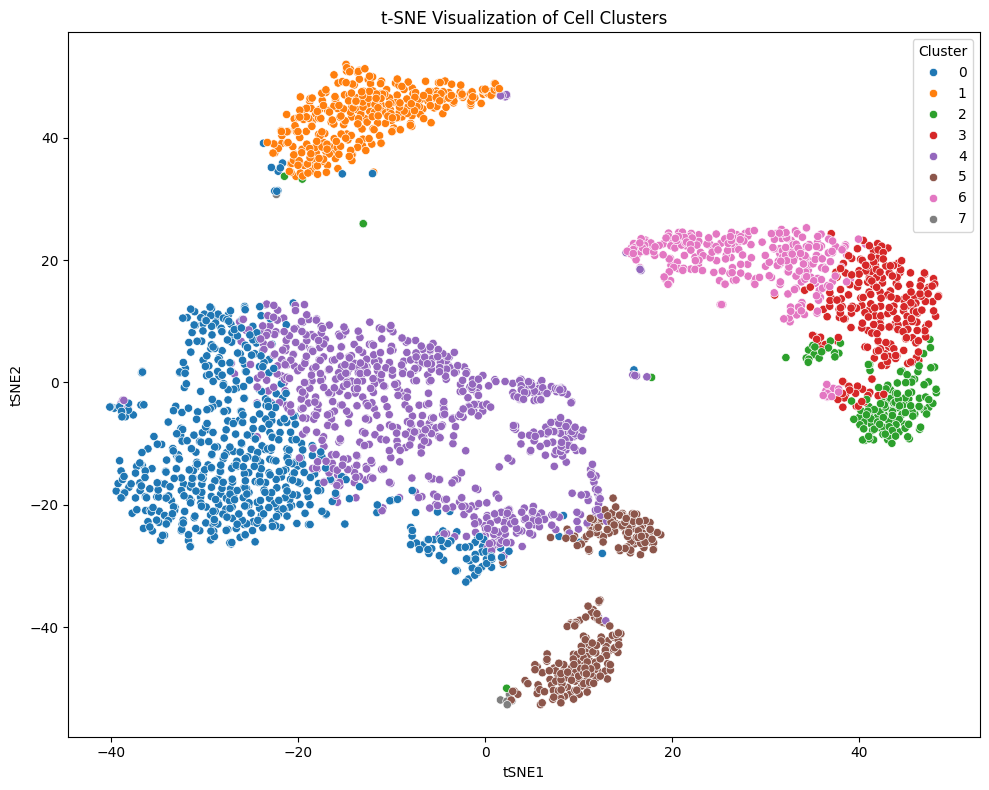

In [39]:
def filter_genes_by_cluster_importance(tfidf_data, n_clusters=10, top_n_per_cluster=200):
    """
    Filter genes based on their importance for distinguishing between clusters.
    This method:
    1. Performs initial clustering on the data
    2. For each cluster, identifies genes that are differentially expressed

    Parameters:
    -----------
    tfidf_data : pandas DataFrame
        TF-IDF transformed gene expression data with cells as rows and genes as columns
    n_clusters : int, optional
        Number of clusters to create
    top_n_per_cluster : int, optional
        Number of top genes to select per cluster

    Returns:
    --------
    filtered_data : pandas DataFrame
        DataFrame containing only the selected genes
    selected_genes : list
        List of selected gene names
    cluster_assignments : pandas Series
        Cluster assignments for each cell
    """
    # First, reduce dimensionality to make clustering more efficient
    print("Running PCA for dimensionality reduction before clustering...")
    pca = PCA(n_components=min(50, tfidf_data.shape[1]))
    pca_result = pca.fit_transform(tfidf_data)

    # Perform clustering
    print(f"Clustering cells into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_assignments = pd.Series(
        kmeans.fit_predict(pca_result),
        index=tfidf_data.index,
        name='cluster'
    )

    # For each cluster, find the most important genes
    selected_genes = []

    for cluster_id in range(n_clusters):
        # Get cells in this cluster
        cluster_cells = cluster_assignments[cluster_assignments == cluster_id].index

        # Get cells not in this cluster
        other_cells = cluster_assignments[cluster_assignments != cluster_id].index

        # Calculate mean expression in this cluster and other clusters
        cluster_mean = tfidf_data.loc[cluster_cells].mean(axis=0)
        other_mean = tfidf_data.loc[other_cells].mean(axis=0)

        # Calculate fold change (log2)
        # Adding small constant to avoid division by zero
        fold_change = np.log2((cluster_mean + 1e-5) / (other_mean + 1e-5))

        # Get top genes with highest positive fold change (overexpressed in this cluster)
        top_overexpressed = fold_change.sort_values(ascending=False).head(top_n_per_cluster).index.tolist()
        selected_genes.extend(top_overexpressed)

        print(f"Cluster {cluster_id}: Selected {len(top_overexpressed)} marker genes")

    # Remove duplicates while preserving order
    selected_genes = list(dict.fromkeys(selected_genes))

    # Filter the TF-IDF data to include only these genes
    filtered_data = tfidf_data[selected_genes]

    print(f"Selected a total of {len(selected_genes)} unique genes based on cluster importance")

    # Visualize the clusters
    # Use t-SNE to project the data to 2D for visualization
    print("Running t-SNE for visualization...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_result = tsne.fit_transform(pca_result)

    # Create a DataFrame for plotting
    tsne_df = pd.DataFrame({
        'tSNE1': tsne_result[:, 0],
        'tSNE2': tsne_result[:, 1],
        'Cluster': cluster_assignments
    }, index=tfidf_data.index)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=tsne_df, x='tSNE1', y='tSNE2', hue='Cluster', palette='tab10')
    plt.title('t-SNE Visualization of Cell Clusters')
    plt.tight_layout()
    plt.show()

    return filtered_data, selected_genes, cluster_assignments

filtered_data_cluster, selected_genes_cluster, cluster_assignments = filter_genes_by_cluster_importance(
    tfidf_transformed_data, n_clusters=8, top_n_per_cluster=300
)

In [40]:
cell_marker = [m for m in cell_marker if m in filtered_data_cluster.columns]

In [41]:
filtered_data_cluster[cell_marker].head()

,GNLY
AAACATACAACCAC-1,0.000000
AAACATTGAGCTAC-1,0.000000
AAACATTGATCAGC-1,1.883439
AAACCGTGCTTCCG-1,0.000000
AAACCGTGTATGCG-1,3.766878


### Combined approach
   - Integrates results from multiple methods
   - Ranks genes by how many methods selected them
   - More robust than any single method

In [42]:
def combine_gene_selection_methods(tfidf_data, top_n_final=2000):
    """
    Combine multiple gene selection methods and select the final set of genes.

    Parameters:
    -----------
    tfidf_data : pandas DataFrame
        TF-IDF transformed gene expression data with cells as rows and genes as columns
    top_n_final : int, optional
        Final number of genes to select

    Returns:
    --------
    filtered_data : pandas DataFrame
        DataFrame containing only the selected genes
    selected_genes : list
        List of selected gene names
    """
    print("Combining results...")

    # Count how many methods selected each gene
    all_genes = list(set(selected_genes_variance + selected_genes_mean + selected_genes_pca + selected_genes_cluster))
    gene_votes = {}

    for gene in all_genes:
        votes = 0
        if gene in selected_genes_variance: votes += 1
        if gene in selected_genes_mean: votes += 1
        if gene in selected_genes_pca: votes += 1
        if gene in selected_genes_cluster: votes += 1
        gene_votes[gene] = votes

    # Sort genes by number of votes (descending) and then by variance (descending)
    gene_variance = tfidf_data.var(axis=0)

    sorted_genes = sorted(
        gene_votes.keys(),
        key=lambda g: (gene_votes[g], gene_variance[g]),
        reverse=True
    )

    # Select top N genes
    final_genes = sorted_genes[:top_n_final]

    # Filter the TF-IDF data to include only these genes
    filtered_data = tfidf_data[final_genes]

    # Count genes by voting category
    vote_counts = {}
    for v in range(1, 5):
        vote_counts[v] = sum(1 for g in gene_votes.values() if g == v)

    print(f"Final gene selection: {len(final_genes)} genes")
    print(f"Vote distribution among all candidate genes:")
    for v, count in vote_counts.items():
        print(f"  {v} vote(s): {count} genes")

    return filtered_data, final_genes

filtered_data_combined, selected_genes_combined = combine_gene_selection_methods(
    tfidf_transformed_data, top_n_final=2000
)

Combining results...
Final gene selection: 2000 genes
Vote distribution among all candidate genes:
  1 vote(s): 2958 genes
  2 vote(s): 1731 genes
  3 vote(s): 643 genes
  4 vote(s): 11 genes


In [43]:
print(filtered_data_combined[cell_marker].head())

                      GNLY
AAACATACAACCAC-1  0.000000
AAACATTGAGCTAC-1  0.000000
AAACATTGATCAGC-1  1.883439
AAACCGTGCTTCCG-1  0.000000
AAACCGTGTATGCG-1  3.766878


In [44]:
os.makedirs(f'data/{version}', exist_ok=True)

In [45]:
# Save selected_genes_combined to CSV
filtered_data_combined.to_csv(f'data/{version}/filtered_data_combined.csv')
print(f"filtered_data_combined saved to {version}/filtered_data_combined.csv")

filtered_data_combined saved to 0.13.2/filtered_data_combined.csv


In [46]:
selected_genes_combined[:8]

['GNLY', 'GZMB', 'CD79A', 'GZMH', 'FGFBP2', 'CST7', 'PRF1', 'TCL1A']

In [47]:
overlap = set(cell_marker) & set(selected_genes_combined[:30])
len(overlap)

1

In [48]:
overlap = set(cell_marker) & set(selected_genes_variance[:30])
len(overlap)

1

In [49]:
# Get the list of genes (columns) from filtered_data_combined
genes_to_keep = filtered_data_combined.columns.intersection(gene_data.columns)

# Subset gene_data to keep only these genes
gene_data_subset = gene_data.loc[:, genes_to_keep]

print(gene_data_subset.head())

                  GNLY  GZMB  CD79A  GZMH  FGFBP2  CST7  PRF1  TCL1A  CCL4  \
AAACATACAACCAC-1   0.0   0.0    0.0   0.0     0.0   0.0   0.0    0.0   0.0   
AAACATTGAGCTAC-1   0.0   0.0    3.0   0.0     0.0   0.0   0.0    0.0   0.0   
AAACATTGATCAGC-1   1.0   0.0    0.0   0.0     1.0   0.0   0.0    0.0   0.0   
AAACCGTGCTTCCG-1   0.0   1.0    0.0   0.0     0.0   0.0   0.0    0.0   0.0   
AAACCGTGTATGCG-1   3.0  12.0    0.0   0.0     2.0   2.0   3.0    0.0   4.0   

                  SPON2  ...  CDT1  AURKB  GGH  COCH  RP11-575L7.8  CDC42EP4  \
AAACATACAACCAC-1    0.0  ...   0.0    0.0  0.0   0.0           0.0       0.0   
AAACATTGAGCTAC-1    0.0  ...   0.0    0.0  0.0   0.0           0.0       0.0   
AAACATTGATCAGC-1    0.0  ...   0.0    0.0  0.0   0.0           0.0       0.0   
AAACCGTGCTTCCG-1    0.0  ...   0.0    1.0  0.0   0.0           0.0       0.0   
AAACCGTGTATGCG-1    4.0  ...   0.0    0.0  0.0   0.0           0.0       0.0   

                  HES6  NDC80  ZBTB32  SCT  
AAACA

In [50]:
# Save selected_genes_combined to CSV
gene_data_subset.to_csv(f'data/{version}/gene_data_subset.csv')
print(f"gene_data_subset saved to {version}/gene_data_subset.csv")

gene_data_subset saved to 0.13.2/gene_data_subset.csv


In [51]:
gene_data_subset = pd.read_csv(f'data/{version}/gene_data_subset.csv', index_col=0)
gene_data_subset.head()

,GNLY,GZMB,CD79A,GZMH,FGFBP2,CST7,PRF1,TCL1A,CCL4,SPON2,...,CDT1,AURKB,GGH,COCH,RP11-575L7.8,CDC42EP4,HES6,NDC80,ZBTB32,SCT
AAACATACAACCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,3.0,12.0,0.0,0.0,2.0,2.0,3.0,0.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
filtered_data_combined = pd.read_csv(f'data/{version}/filtered_data_combined.csv', index_col=0)
filtered_data_combined.head()

,GNLY,GZMB,CD79A,GZMH,FGFBP2,CST7,PRF1,TCL1A,CCL4,SPON2,...,CDT1,AURKB,GGH,COCH,RP11-575L7.8,CDC42EP4,HES6,NDC80,ZBTB32,SCT
AAACATACAACCAC-1,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.000000,0.000000,3.943443,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,1.883439,0.000000,0.000000,0.0,2.223370,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.000000,2.156670,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,4.447558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,3.766878,7.980627,0.000000,0.0,3.523958,2.875336,3.936966,0.0,5.103974,5.667604,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


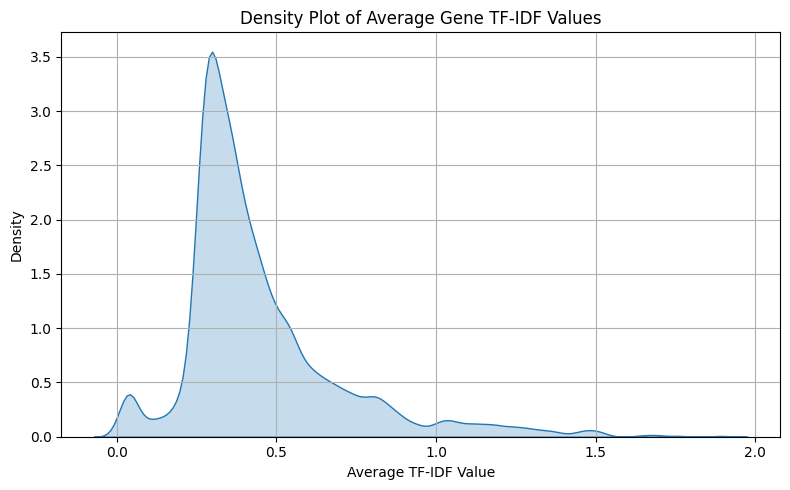

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'filtered_data_combined' is your DataFrame

# Calculate the average TF-IDF value for each gene (i.e., each column)
gene_means = filtered_data_combined.mean(axis=0)

# Plot density plot (KDE) of average TF-IDF values across genes
plt.figure(figsize=(8, 5))
sns.kdeplot(gene_means, fill=True, bw_adjust=0.5)
plt.xlabel('Average TF-IDF Value')
plt.ylabel('Density')
plt.title('Density Plot of Average Gene TF-IDF Values')
plt.grid(True)
plt.tight_layout()
plt.show()


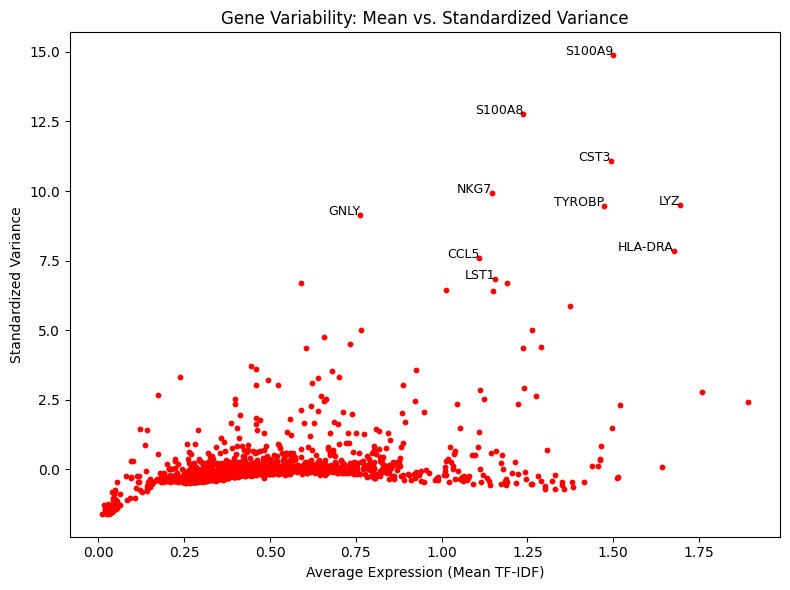

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean and variance for each gene
gene_means = filtered_data_combined.mean(axis=0)
gene_vars = filtered_data_combined.var(axis=0)

# Standardize the variance (Z-score)
standardized_var = (gene_vars - gene_vars.mean()) / gene_vars.std()

# Create a DataFrame for easier handling
gene_stats = pd.DataFrame({
    'mean': gene_means,
    'variance': gene_vars,
    'standardized_var': standardized_var
})

# Select top 2000 genes by standardized variance
top_2000 = gene_stats.sort_values('standardized_var', ascending=False).head(2000)
other_genes = gene_stats.drop(top_2000.index)

# Get top 10 genes for labeling
top_10 = top_2000.head(10)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(other_genes['mean'], other_genes['standardized_var'], color='black', s=10)
plt.scatter(top_2000['mean'], top_2000['standardized_var'], color='red', s=10)
for gene in top_10.index:
    plt.text(top_10.loc[gene, 'mean'], top_10.loc[gene, 'standardized_var'], gene, fontsize=9, ha='right')
plt.xlabel('Average Expression (Mean TF-IDF)')
plt.ylabel('Standardized Variance')
plt.title('Gene Variability: Mean vs. Standardized Variance')
plt.tight_layout()
plt.show()


# PCA + KMeans + TSNE

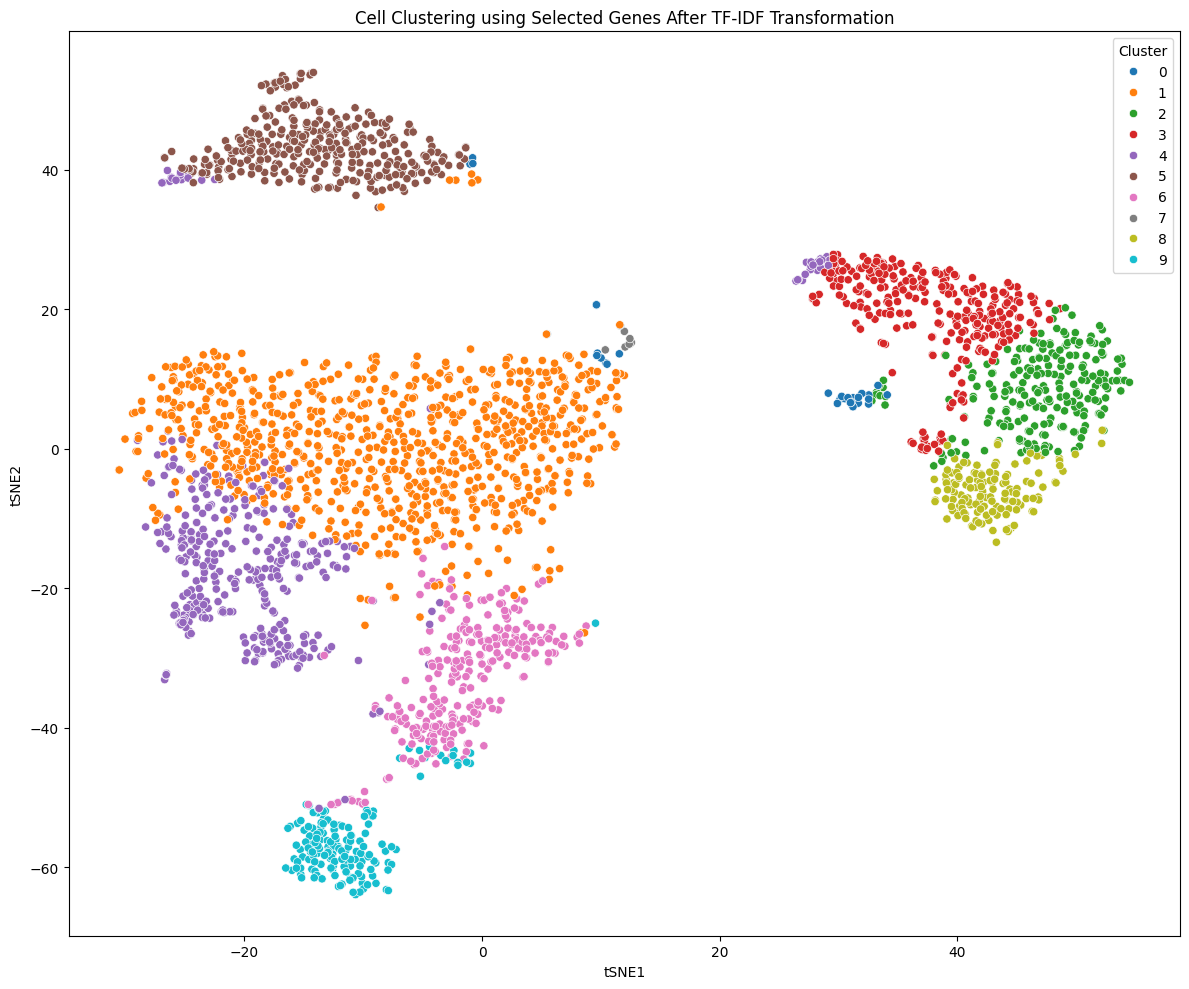

In [55]:
# Now you can use the filtered data for downstream clustering

# Use the combined filtered data
X = filtered_data_combined

# Dimensionality reduction with PCA first (for efficiency)
pca = PCA(n_components=min(50, X.shape[1]))
pca_result = pca.fit_transform(X)

# t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(pca_result)

# Final clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
final_clusters = kmeans.fit_predict(pca_result)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame({
    'tSNE1': tsne_result[:, 0],
    'tSNE2': tsne_result[:, 1],
    'Cluster': final_clusters
}, index=X.index)

# Plot final clustering
plt.figure(figsize=(12, 10))
sns.scatterplot(data=tsne_df, x='tSNE1', y='tSNE2', hue='Cluster', palette='tab10')
plt.title('Cell Clustering using Selected Genes After TF-IDF Transformation')
plt.tight_layout()
plt.show()

In [56]:
tsne_df.to_csv(f"data/{version}/tsne_df_pca.csv")

In [57]:
tsne_df_pca = pd.read_csv(f"data/{version}/tsne_df_pca.csv", index_col=0)
tsne_df_pca.head()

,tSNE1,tSNE2,Cluster
AAACATACAACCAC-1,-0.072360,-21.704940,6
AAACATTGAGCTAC-1,-1.837243,40.550260,5
AAACATTGATCAGC-1,7.405252,12.935945,1
AAACCGTGCTTCCG-1,42.670105,4.393787,2
AAACCGTGTATGCG-1,-14.554901,-51.130200,9


In [58]:
X = tsne_df_pca[['tSNE1', 'tSNE2']].values
labels = tsne_df_pca['Cluster'].values

score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.322


## Comparision

### Read Seurat Clusters

In [104]:
seurat_clusters = pd.read_csv("data/pbmc_metadata.csv", index_col=0)
# seurat_clusters.reset_index(inplace=True)

In [105]:
seurat_clusters.head().to_clipboard()
seurat_clusters

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters
AAACATACAACCAC-1,pbmc3k,2419,779,3.017776,2,2
AAACATTGAGCTAC-1,pbmc3k,4903,1352,3.793596,3,3
AAACATTGATCAGC-1,pbmc3k,3147,1129,0.889736,2,2
AAACCGTGCTTCCG-1,pbmc3k,2639,960,1.743085,1,1
AAACCGTGTATGCG-1,pbmc3k,980,521,1.224490,6,6
...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,pbmc3k,3459,1153,2.110437,1,1
TTTCTACTGAGGCA-1,pbmc3k,3443,1224,0.929422,3,3
TTTCTACTTCCTCG-1,pbmc3k,1684,622,2.197150,3,3
TTTGCATGAGAGGC-1,pbmc3k,1022,452,2.054795,3,3


In [61]:
tsne_df_pca

,tSNE1,tSNE2,Cluster
AAACATACAACCAC-1,-0.072360,-21.704940,6
AAACATTGAGCTAC-1,-1.837243,40.550260,5
AAACATTGATCAGC-1,7.405252,12.935945,1
AAACCGTGCTTCCG-1,42.670105,4.393787,2
AAACCGTGTATGCG-1,-14.554901,-51.130200,9
...,...,...,...
TTTCGAACTCTCAT-1,46.708393,10.533429,2
TTTCTACTGAGGCA-1,11.593126,17.756895,1
TTTCTACTTCCTCG-1,-14.739459,46.746487,5
TTTGCATGAGAGGC-1,-23.294231,41.443443,5


### Cluster Contingency Table



In [110]:
def compare_clusters(tsne_df, seurat_clusters):
    """
    Compare tSNE clusters with Seurat clusters and compute metrics

    Args:
        tsne_df (pd.DataFrame): DataFrame with cell IDs as index and 'Cluster' column
        seurat_clusters (pd.DataFrame): DataFrame with cell IDs as index and 'seurat_clusters' column

    Returns:
        pd.DataFrame: Contingency table with margins
    """

    # Create a mapping of cell IDs to tSNE clusters
    cell_to_cluster = dict(zip(tsne_df.index, tsne_df['Cluster']))
    # print(cell_to_cluster)

    # Find shared cells
    shared_cells = set(tsne_df.index).intersection(set(seurat_clusters.index))
    # print(shared_cells)
    # print('GCTACGCTAGAATG-1' in shared_cells)

    # Create a combined dataframe with both cluster assignments
    combined = pd.DataFrame({
        'tsne_cluster': [ [cell] for cell in shared_cells],
        'seurat_cluster': [seurat_clusters.loc[cell, 'seurat_clusters'] for cell in shared_cells]
    })
    print(combined.head())

    # Create contingency table with margins
    contingency_with_margins = pd.crosstab(
        combined['tsne_cluster'],
        combined['seurat_cluster'],
        margins=True,
        margins_name='Total'
    )

    # Calculate metrics
    ari = adjusted_rand_score(combined['seurat_cluster'], combined['tsne_cluster'])
    nmi = normalized_mutual_info_score(combined['seurat_cluster'], combined['tsne_cluster'])

    print(f"Adjusted Rand Index: {ari:.4f}")
    print(f"Normalized Mutual Information: {nmi:.4f}")
    print("\nContingency Table (rows: tSNE clusters, columns: Seurat clusters):")

    return contingency_with_margins

In [111]:
cell = 'GCTACGCTAGAATG-1'
for idx in seurat_clusters.index:
    if idx.startswith(cell):
        print("Starts with:", repr(idx))
        print(f"-{idx}-")
    if cell in idx:
        print("Contains:", repr(idx))
        print(f"-{idx}-")
    if idx.strip() == cell:
        print("Matches when stripped:", repr(idx))
        print(f"-{idx}-")


Starts with: 'GCTACGCTAGAATG-1'
-GCTACGCTAGAATG-1-
Contains: 'GCTACGCTAGAATG-1'
-GCTACGCTAGAATG-1-
Matches when stripped: 'GCTACGCTAGAATG-1'
-GCTACGCTAGAATG-1-


In [112]:
# Example usage:
contingency_table = compare_clusters(tsne_df_pca, seurat_clusters)
print(contingency_table)

         tsne_cluster  seurat_cluster
0  [GCTACGCTAGAATG-1]               0
1  [CTTACAACTCCCGT-1]               1
2  [TGAGCTGACTGGAT-1]               1
3  [CGAAGGGATCCGAA-1]               3
4  [ATGAAGGACCTTAT-1]               3


TypeError: Cannot broadcast np.ndarray with operand of type <class 'list'>

### Visualize Contingency Table

In [66]:
def plot_heatmaps(contingency_table):
    """
    Create sorted heatmaps from contingency table, aligning Seurat clusters to tSNE clusters
    by maximizing row-wise percentage overlap.

    Args:
        contingency_table (pd.DataFrame): Contingency table with margins from compare_clusters function

    Returns:
        tuple: (contingency, contingency_percent) - cleaned and sorted count and percentage tables
    """
    # Remove the 'Total' row and column if present
    contingency = contingency_table.drop(index='Total', columns='Total', errors='ignore')

    # Compute row percentages
    contingency_percent = contingency.div(contingency.sum(axis=1), axis=0) * 100

    # For each tSNE cluster, find the Seurat cluster with the highest percentage
    best_matches = contingency_percent.idxmax(axis=1)

    # Order Seurat clusters by their first appearance as a best match
    # This aligns Seurat clusters to tSNE clusters by their strongest association
    ordered_seurat = []
    for cluster in best_matches:
        if cluster not in ordered_seurat:
            ordered_seurat.append(cluster)
    # Add any remaining clusters not matched as best (to keep all columns)
    ordered_seurat += [c for c in contingency.columns if c not in ordered_seurat]

    # Reorder columns
    contingency = contingency[ordered_seurat]
    contingency_percent = contingency_percent[ordered_seurat]

    # Plot heatmap of counts
    plt.figure(figsize=(10, 8))
    sns.heatmap(contingency, annot=True, cmap='Blues', fmt='d', cbar=True)
    plt.xlabel('Seurat Clusters')
    plt.ylabel('Topic Clusters')
    plt.title('Cluster Correspondence Heatmap (Cell Counts)')
    plt.tight_layout()
    plt.savefig('cluster_heatmap_counts.png', dpi=300)
    plt.show()

    # Plot heatmap of percentages
    plt.figure(figsize=(10, 8))
    sns.heatmap(contingency_percent, annot=True, cmap='Blues', fmt='.1f', cbar=True)
    plt.xlabel('Seurat Clusters')
    plt.ylabel('Topic Clusters')
    plt.title('Cluster Correspondence Heatmap (Row Percentages)')
    plt.tight_layout()
    plt.savefig('cluster_heatmap_percentages.png', dpi=300)
    plt.show()

    return contingency, contingency_percent

In [67]:
# Plot sorted heatmaps
counts, percentages = plot_heatmaps(contingency_table)

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1000x800 with 0 Axes>

### Cluster Comparison Visualization

In [68]:
def plot_cluster_comparison_tsne(tsne_df, seurat_clusters):
    """
    Plot tSNE and Seurat clusters side by side.

    Args:
        tsne_df (pd.DataFrame): DataFrame with cell IDs as index, and columns 'tSNE1', 'tSNE2', 'Cluster'
        seurat_clusters (pd.DataFrame): DataFrame with cell IDs as index and 'seurat_clusters' column
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Copy and rename for clarity
    viz_df = tsne_df.copy()
    viz_df.rename(columns={'Cluster': 'tsne_cluster'}, inplace=True)

    # Add seurat clusters by aligning on the index
    viz_df['seurat_cluster'] = seurat_clusters['seurat_clusters']

    # Remove any rows with missing cluster assignments (optional, for clean plotting)
    viz_df = viz_df.dropna(subset=['tsne_cluster', 'seurat_cluster'])

    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot tSNE clusters
    sns.scatterplot(
        x='tSNE1', y='tSNE2', hue='tsne_cluster', palette='tab10',
        data=viz_df, alpha=0.7, ax=ax1, legend='full'
    )
    ax1.set_title('tSNE Clustering')
    ax1.legend(title='tSNE Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Plot Seurat clusters
    sns.scatterplot(
        x='tSNE1', y='tSNE2', hue='seurat_cluster', palette='Set1',
        data=viz_df, alpha=0.7, ax=ax2, legend='full'
    )
    ax2.set_title('Seurat Clusters')
    ax2.legend(title='Seurat Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig('cluster_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

/var/folders/kz/qfmfpghs1qj4qdcnl6f1hlb00000gn/T/ipykernel_5577/1848704350.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kz/qfmfpghs1qj4qdcnl6f1hlb00000gn/T/ipykernel_5577/1848704350.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(title='tSNE Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
/var/folders/kz/qfmfpghs1qj4qdcnl6f1hlb00000gn/T/ipykernel_5577/1848704350.py:34: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/kz/qfmfpghs1qj4qdcnl6f1hlb00000gn/T/ipykernel_5577/1848704350.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='Seurat Cluster', bbox_to_anchor=(1.05, 1)

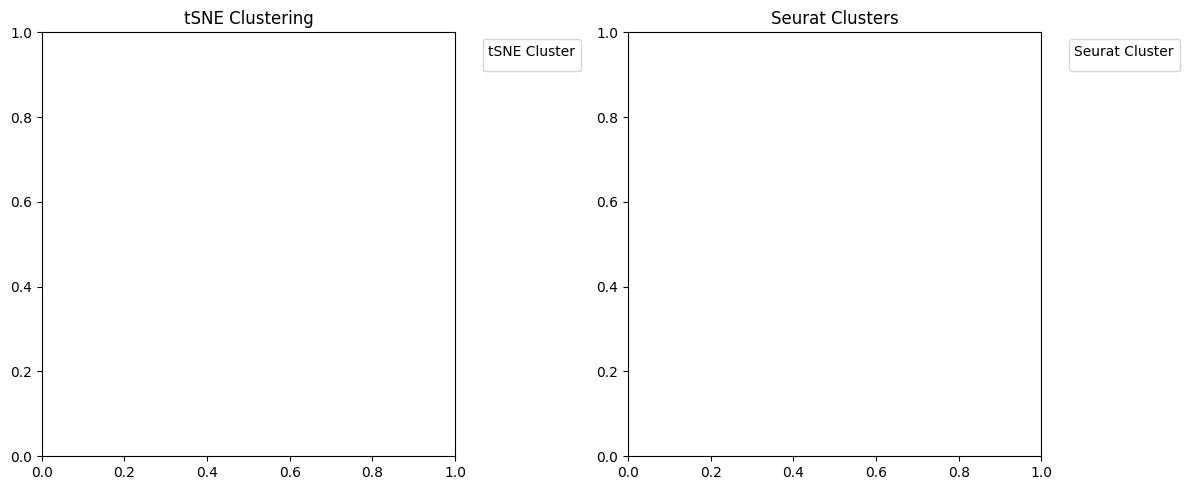

In [69]:
plot_cluster_comparison_tsne(tsne_df_pca, seurat_clusters)

# Pyro LDA

### Data Prepare

#### Read Cell_Gene Table

In [70]:
gene_data_subset = pd.read_csv(f"data/{version}/gene_data_subset.csv", index_col = 0)

In [71]:
gene_data_subset.shape

(2700, 2000)

In [72]:
gene_data_subset.head()

,GNLY,GZMB,CD79A,GZMH,FGFBP2,CST7,PRF1,TCL1A,CCL4,SPON2,...,CDT1,AURKB,GGH,COCH,RP11-575L7.8,CDC42EP4,HES6,NDC80,ZBTB32,SCT
AAACATACAACCAC-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,3.0,12.0,0.0,0.0,2.0,2.0,3.0,0.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Re-Normalization (Optinal)

In [73]:
def re_normalize_for_multinomial(tfidf_data):
    """
    Re-normalize TF-IDF transformed data for multinomial model.
    This ensures all rows sum to 1 again after TF-IDF transformation.
    """
    # Check for negative values (shouldn't occur, but just to be safe)
    if (tfidf_data < 0).any().any():
        print("Warning: Negative values found after TF-IDF")
        tfidf_data = tfidf_data.clip(lower=0)

    # Check for zero rows
    zero_rows = (tfidf_data.sum(axis=1) == 0)
    if zero_rows.any():
        print(f"Warning: {zero_rows.sum()} cells have zero values after TF-IDF")
        # Add a small pseudo-count to zero rows
        tfidf_data.loc[zero_rows] = 1e-6

    # Normalize each cell (row) to sum to 1 (convert to probabilities)
    row_sums = tfidf_data.sum(axis=1)
    normalized_data = tfidf_data.div(row_sums, axis=0)

    print("Data re-normalized for multinomial model after TF-IDF")
    return normalized_data

re_normalized_data = re_normalize_for_multinomial(filtered_data_combined)

Data re-normalized for multinomial model after TF-IDF


In [74]:
re_normalized_data.head()

,GNLY,GZMB,CD79A,GZMH,FGFBP2,CST7,PRF1,TCL1A,CCL4,SPON2,...,CDT1,AURKB,GGH,COCH,RP11-575L7.8,CDC42EP4,HES6,NDC80,ZBTB32,SCT
AAACATACAACCAC-1,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGAGCTAC-1,0.000000,0.000000,0.002669,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACATTGATCAGC-1,0.001496,0.000000,0.000000,0.0,0.001766,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGCTTCCG-1,0.000000,0.001899,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.003916,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCGTGTATGCG-1,0.007364,0.015601,0.000000,0.0,0.006889,0.005621,0.007696,0.0,0.009977,0.011079,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Conver to Torch Tensor

In [75]:
# =============================================================================
# CONVERT DATA TO PYTORCH TENSORS
# Prepare data for PyroLDA model training
# =============================================================================

try:
    print("="*80)
    print("PREPARING DATA FOR PYTORCH/PYRO")
    print("="*80)

    # Verify gene_data_subset exists
    if 'gene_data_subset' not in locals() and 'gene_data_subset' not in globals():
        print("⚠ WARNING: 'gene_data_subset' not found.")
        print("  Attempting to use available data...")

        # Try to find the most recent processed data
        for var_name in ['tfidf_transformed_data', 'filtered_gene_data', 'log_normalized_data', 'gene_data']:
            if var_name in locals() or var_name in globals():
                gene_data_subset = eval(var_name)
                print(f"  → Using '{var_name}' as gene_data_subset")
                break
        else:
            raise NameError("No suitable gene expression data found!")

    # Extract metadata
    cell_names = gene_data_subset.index.tolist()
    gene_names = gene_data_subset.columns.tolist()

    print(f"\n✓ Data dimensions:")
    print(f"  Cells: {len(cell_names)}")
    print(f"  Genes: {len(gene_names)}")

    # Validate data before conversion
    if gene_data_subset.isna().any().any():
        print("⚠ NaN values detected. Filling with zeros...")
        gene_data_subset = gene_data_subset.fillna(0)

    if (gene_data_subset < 0).any().any():
        print("⚠ Negative values detected. Taking absolute value...")
        gene_data_subset = gene_data_subset.abs()

    # Convert to torch tensor
    print("\nConverting to PyTorch tensor...")
    cells = torch.from_numpy(gene_data_subset.values).float()

    # Validate tensor
    assert cells.shape[0] == len(cell_names), "Tensor row mismatch!"
    assert cells.shape[1] == len(gene_names), "Tensor column mismatch!"
    assert not torch.isnan(cells).any(), "NaN values in tensor!"
    assert not torch.isinf(cells).any(), "Inf values in tensor!"

    print(f"✓ Tensor created successfully:")
    print(f"  Shape: {cells.shape}")
    print(f"  dtype: {cells.dtype}")
    print(f"  Range: [{cells.min():.4f}, {cells.max():.4f}]")
    print(f"  Device: {cells.device}")

except NameError as e:
    print(f"✗ Variable not found: {e}")
    print("  Cannot proceed with model training without gene expression data.")
    raise
except Exception as e:
    print(f"✗ CRITICAL ERROR in tensor conversion: {type(e).__name__}")
    print(f"  {str(e)}")
    raise


PREPARING DATA FOR PYTORCH/PYRO

✓ Data dimensions:
  Cells: 2700
  Genes: 2000

Converting to PyTorch tensor...
✓ Tensor created successfully:
  Shape: torch.Size([2700, 2000])
  dtype: torch.float32
  Range: [0.0000, 238.0000]
  Device: cpu


In [76]:
vocab = pd.DataFrame({'gene': gene_names, 'index': range(len(gene_names))})

### ProdLDA Architecture

The key components of your model are:

- An Encoder that maps gene expression profiles to topic distributions
- A Decoder that reconstructs gene expression from topic distributions
- A ProdLDA wrapper that defines the model and guide for SVI (Stochastic Variational Inference)

The model uses a logistic-normal distribution instead of a Dirichlet prior, which often works better for biological data.

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.optim import ClippedAdam
from pyro.poutine import scale

# -------------------------
# Model & Guide Definition
# -------------------------

class Encoder(nn.Module):
    def __init__(self, vocab_size, num_topics, hidden, dropout):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        self.fc1 = nn.Linear(vocab_size, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fcmu = nn.Linear(hidden, num_topics)
        self.fclv = nn.Linear(hidden, num_topics)
        self.bnmu = nn.BatchNorm1d(num_topics, affine=False)
        self.bnlv = nn.BatchNorm1d(num_topics, affine=False)

    def forward(self, inputs):
        h = F.softplus(self.fc1(inputs))
        h = F.softplus(self.fc2(h))
        h = self.drop(h)
        logtheta_loc = self.bnmu(self.fcmu(h))
        logtheta_logvar = self.bnlv(self.fclv(h))
        logtheta_scale = (0.5 * logtheta_logvar).exp()
        return logtheta_loc, logtheta_scale

class Decoder(nn.Module):
    def __init__(self, vocab_size, num_topics, dropout):
        super().__init__()
        self.beta = nn.Linear(num_topics, vocab_size, bias=False)
        self.bn = nn.BatchNorm1d(vocab_size, affine=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, inputs):
        inputs = self.drop(inputs)
        return F.softmax(self.bn(self.beta(inputs)), dim=1)

class ProdLDA(nn.Module):
    def __init__(self, vocab_size, num_topics, hidden, dropout):
        super().__init__()
        self.vocab_size = vocab_size
        self.num_topics = num_topics
        self.encoder = Encoder(vocab_size, num_topics, hidden, dropout)
        self.decoder = Decoder(vocab_size, num_topics, dropout)

    # === Stability fix ===
    # **Changed** match latent name with guide ("logtheta" instead of "theta")
    def model(self, docs, kl_weight=1.0):  # Add kl_weight to match guide signature
        pyro.module("decoder", self.decoder)
        with pyro.plate("documents", docs.shape[0]):
            logtheta = pyro.sample(
                "logtheta",
                dist.Normal(
                    torch.zeros(docs.shape[0], self.num_topics, device=docs.device),
                    torch.ones(docs.shape[0], self.num_topics, device=docs.device)
                ).to_event(1)
            )
            theta = F.softmax(logtheta, dim=-1)  # convert to simplex

            count_param = self.decoder(theta)
            total_count = int(docs.sum(-1).max())
            pyro.sample(
                "obs",
                dist.Multinomial(total_count, count_param),
                obs=docs
            )


    # === Stability fix ===
    # **Changed** add `kl_weight` and apply via pyro.poutine.scale
    def guide(self, docs, kl_weight=1.0):
        pyro.module("encoder", self.encoder)
        with pyro.plate("documents", docs.shape[0]):
            logtheta_loc, logtheta_scale = self.encoder(docs)
            with scale(scale=kl_weight):  # scales the KL divergence term
                pyro.sample(
                    "logtheta",
                    dist.Normal(logtheta_loc, logtheta_scale).to_event(1)
                )

    def beta(self):
        return self.decoder.beta.weight.cpu().detach().T

#### Training

ProdLDA(
  (encoder): Encoder(
    (drop): Dropout(p=0.2, inplace=False)
    (fc1): Linear(in_features=2000, out_features=100, bias=True)
    (fc2): Linear(in_features=100, out_features=100, bias=True)
    (fcmu): Linear(in_features=100, out_features=50, bias=True)
    (fclv): Linear(in_features=100, out_features=50, bias=True)
    (bnmu): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (bnlv): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
  )
  (decoder): Decoder(
    (beta): Linear(in_features=50, out_features=2000, bias=False)
    (bn): BatchNorm1d(2000, eps=1e-05, momentum=0.1, affine=False, track_running_stats=True)
    (drop): Dropout(p=0.2, inplace=False)
  )
)


  0%|          | 0/50 [00:00<?, ?it/s]/Users/jacky/workspaces/scRNA-clustering-FTCNC/.venv/lib/python3.13/site-packages/pyro/infer/traceenum_elbo.py:355: UserWarning: TraceEnum_ELBO found no sample sites configured for enumeration. If you want to enumerate sites, you need to @config_enumerate or set infer={"enumerate": "sequential"} or infer={"enumerate": "parallel"}? If you do not want to enumerate, consider using Trace_ELBO instead.
  warnings.warn(
/Users/jacky/workspaces/scRNA-clustering-FTCNC/.venv/lib/python3.13/site-packages/pyro/infer/traceenum_elbo.py:355: UserWarning: TraceEnum_ELBO found no sample sites configured for enumeration. If you want to enumerate sites, you need to @config_enumerate or set infer={"enumerate": "sequential"} or infer={"enumerate": "parallel"}? If you do not want to enumerate, consider using Trace_ELBO instead.
  warnings.warn(
100%|██████████| 50/50 [00:20<00:00,  2.49it/s, epoch_loss=1.78e+03]


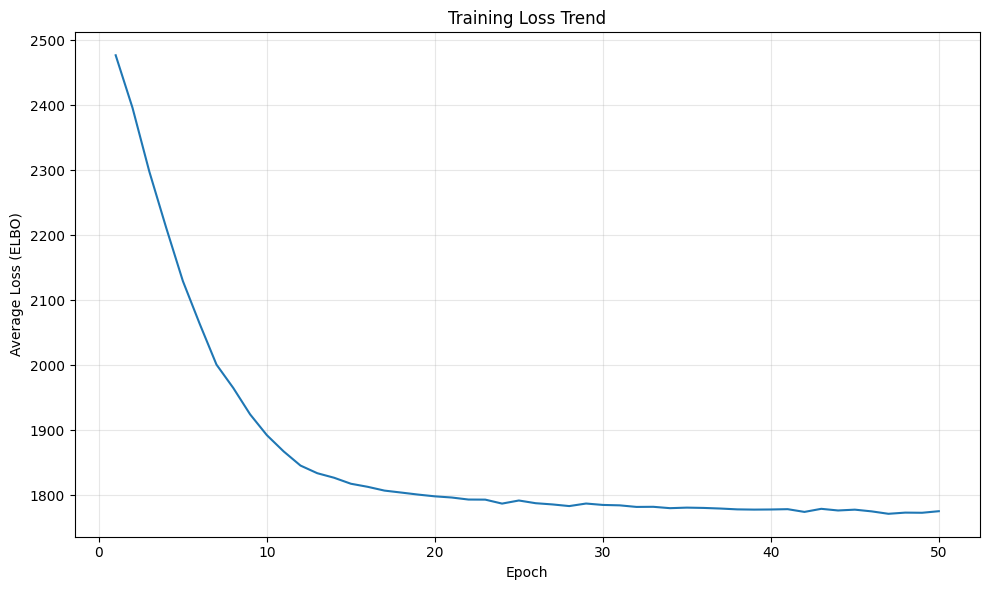

In [78]:
import math
import torch
import pyro
from tqdm import trange
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.optim import ClippedAdam

# -------------------------
# Global Setup
# -------------------------
seed = 0
torch.manual_seed(seed)
pyro.set_rng_seed(seed)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_topics = 50
cells = cells.to(device)
batch_size = 32

# === Stability fix ===
# **Changed** lower learning rate for stable optimization
learning_rate = 5e-4
num_epochs = 50

# -------------------------
# Model Instantiation
# -------------------------
pyro.clear_param_store()

prodLDA = ProdLDA(
    vocab_size=cells.shape[1],
    num_topics=num_topics,
    hidden=100,
    dropout=0.2
)
prodLDA.to(device)
print(prodLDA.to(device))

# -------------------------
# Optimizer and SVI Setup
# -------------------------
# === Stability fix ===
# **Changed** use gradient-clipped Adam with adjusted betas
optimizer = ClippedAdam({"lr": learning_rate, "betas": (0.8, 0.99)})

# === Stability fix ===
# **Changed** use TraceEnum_ELBO for reduced gradient variance
svi = SVI(
    prodLDA.model,
    prodLDA.guide,
    optimizer,
    loss=TraceEnum_ELBO(max_plate_nesting=1)
)

num_batches = int(np.ceil(cells.shape[0] / batch_size))

# -------------------------
# KL Annealing Function
# -------------------------
# === Stability fix ===
# **Changed** ramp up KL term slowly
def kl_weight(step, n_warmup=1000):
    return min(1.0, step / n_warmup)

# -------------------------
# Training Loop
# -------------------------
global_step = 0
bar = trange(num_epochs)

losses = []
for epoch in bar:
    running_loss = 0.0
    for i in range(num_batches):
        batch_cells = cells[i * batch_size:(i + 1) * batch_size, :]

        # === Stability fix ===
        # **Changed** pass kl_weight to guide
        kl = max(kl_weight(global_step), 1e-8)  # === Stability fix ===
        loss = svi.step(batch_cells, kl)
        running_loss += loss / batch_cells.size(0)
        global_step += 1

    epoch_loss = running_loss / num_batches  # Properly average the loss
    losses.append(epoch_loss)
    bar.set_postfix(epoch_loss='{:.2e}'.format(epoch_loss))

# After training, plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses)+1), losses)
plt.xlabel('Epoch')
plt.ylabel('Average Loss (ELBO)')
plt.title('Training Loss Trend')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_trend.png', dpi=300)
plt.show()

##### Extract Tables

In [79]:
def extract_topic_gene_table(model, gene_names):
    """
    Extract the topic-gene matrix from the trained model and convert to probabilities.

    Args:
        model: Trained ProdLDA model
        gene_names: List of gene names

    Returns:
        DataFrame: A table with topics as rows and genes as columns, containing probability distributions
    """
    # Get the beta matrix (topics x genes)
    beta_matrix = model.beta()  # This returns a tensor

    # Apply softmax along gene dimension (dim=1) to get probability distributions
    # Each row (topic) will sum to 1 after this operation
    topic_gene_probs = F.softmax(beta_matrix, dim=1).cpu().detach().numpy()

    # Create a DataFrame
    topic_gene_df = pd.DataFrame(
        topic_gene_probs,
        index=[f"Topic_{i+1}" for i in range(topic_gene_probs.shape[0])],
        columns=gene_names
    )

    return topic_gene_df

# Usage example:
# After training your model, extract the table:
topic_gene_df = extract_topic_gene_table(prodLDA, gene_names)
topic_gene_df.to_csv(f'data/{version}/topic_gene_df.csv')

In [80]:
topic_gene_df.head()

,GNLY,GZMB,CD79A,GZMH,FGFBP2,CST7,PRF1,TCL1A,CCL4,SPON2,...,CDT1,AURKB,GGH,COCH,RP11-575L7.8,CDC42EP4,HES6,NDC80,ZBTB32,SCT
Topic_1,0.000508,0.000546,0.000439,0.000609,0.000559,0.000638,0.000571,0.000478,0.000538,0.000528,...,0.000515,0.000517,0.000512,0.000519,0.000515,0.000513,0.000515,0.000517,0.000514,0.000512
Topic_2,0.000418,0.000443,0.000691,0.000483,0.000485,0.000484,0.000467,0.000641,0.000478,0.000501,...,0.000525,0.000522,0.000524,0.000519,0.000522,0.000521,0.000522,0.000521,0.000521,0.000526
Topic_3,0.000483,0.000478,0.000440,0.000500,0.000514,0.000500,0.000490,0.000494,0.000517,0.000524,...,0.000524,0.000530,0.000528,0.000533,0.000528,0.000533,0.000531,0.000530,0.000533,0.000527
Topic_4,0.000389,0.000419,0.000456,0.000464,0.000463,0.000480,0.000454,0.000492,0.000475,0.000485,...,0.000523,0.000514,0.000517,0.000509,0.000516,0.000513,0.000514,0.000515,0.000512,0.000521
Topic_5,0.000462,0.000469,0.000416,0.000483,0.000485,0.000481,0.000474,0.000471,0.000492,0.000501,...,0.000503,0.000511,0.000510,0.000512,0.000507,0.000516,0.000511,0.000508,0.000511,0.000507


In [81]:
topic_gene_df = pd.read_csv(f'data/{version}/topic_gene_df.csv',index_col=0)
topic_gene_df.head()

,GNLY,GZMB,CD79A,GZMH,FGFBP2,CST7,PRF1,TCL1A,CCL4,SPON2,...,CDT1,AURKB,GGH,COCH,RP11-575L7.8,CDC42EP4,HES6,NDC80,ZBTB32,SCT
Topic_1,0.000508,0.000546,0.000439,0.000609,0.000559,0.000638,0.000571,0.000478,0.000538,0.000528,...,0.000515,0.000517,0.000512,0.000519,0.000515,0.000513,0.000515,0.000517,0.000514,0.000512
Topic_2,0.000418,0.000443,0.000691,0.000483,0.000485,0.000484,0.000467,0.000641,0.000478,0.000501,...,0.000525,0.000522,0.000524,0.000519,0.000522,0.000521,0.000522,0.000521,0.000521,0.000526
Topic_3,0.000483,0.000478,0.000440,0.000500,0.000514,0.000500,0.000490,0.000494,0.000517,0.000524,...,0.000524,0.000530,0.000528,0.000533,0.000528,0.000533,0.000531,0.000530,0.000533,0.000527
Topic_4,0.000389,0.000419,0.000456,0.000464,0.000463,0.000480,0.000454,0.000492,0.000475,0.000485,...,0.000523,0.000514,0.000517,0.000509,0.000516,0.000513,0.000514,0.000515,0.000512,0.000521
Topic_5,0.000462,0.000469,0.000416,0.000483,0.000485,0.000481,0.000474,0.000471,0.000492,0.000501,...,0.000503,0.000511,0.000510,0.000512,0.000507,0.000516,0.000511,0.000508,0.000511,0.000507


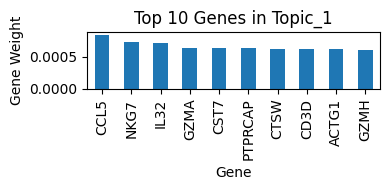

In [82]:
import matplotlib.pyplot as plt

# Choose a topic to visualize, e.g., 'Topic_1'
topic_name = 'Topic_1'
top_n = 10  # Number of top genes to display

# Get the gene distribution for the chosen topic and sort by weight
topic_dist = topic_gene_df.loc[topic_name].sort_values(ascending=False).head(top_n)

plt.figure(figsize=(4, 2))
topic_dist.plot(kind='bar')
plt.title(f'Top {top_n} Genes in {topic_name}')
plt.ylabel('Gene Weight')
plt.xlabel('Gene')
plt.tight_layout()
plt.show()


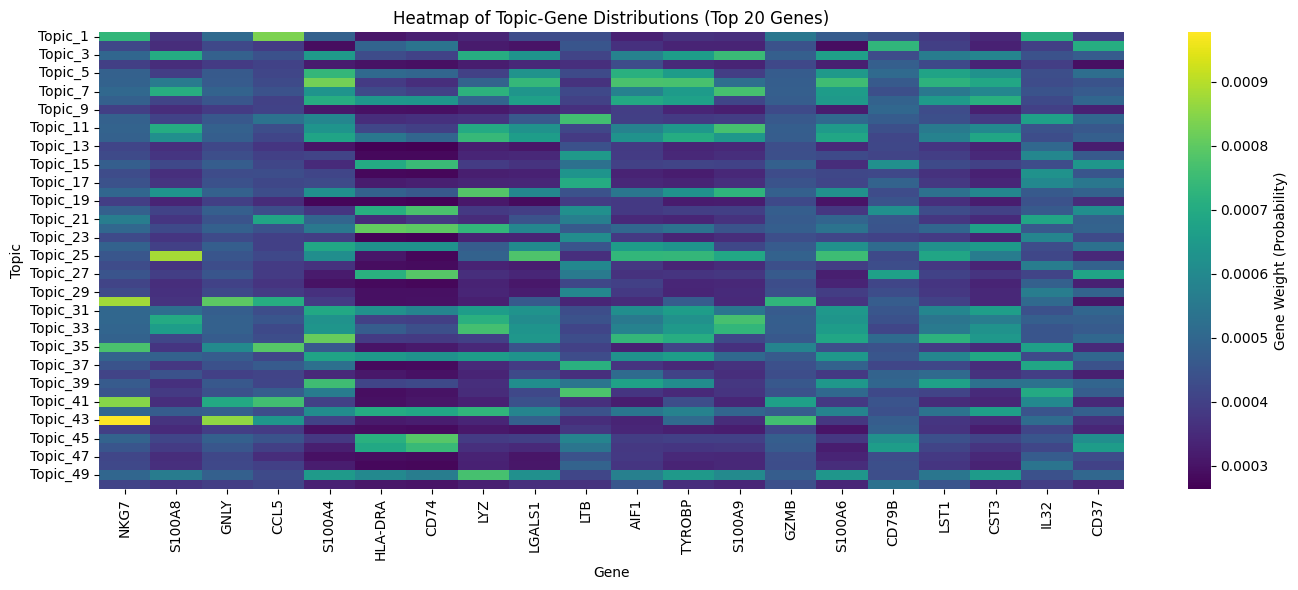

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the top 20 genes with the highest maximum weight across any topic
top_genes = topic_gene_df.max(axis=0).sort_values(ascending=False).head(20).index

# Subset the DataFrame to include only these top genes
subset = topic_gene_df[top_genes]

# Plot the heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(subset, cmap='viridis', annot=False, cbar_kws={'label': 'Gene Weight (Probability)'})
plt.title('Heatmap of Topic-Gene Distributions (Top 20 Genes)')
plt.ylabel('Topic')
plt.xlabel('Gene')
plt.tight_layout()
plt.show()


In [84]:
cell_topic_df = pd.read_csv(f'data/{version}/cell_topic_df.csv', index_col=0)
cell_topic_df

FileNotFoundError: [Errno 2] No such file or directory: 'data/0.13.2/cell_topic_df.csv'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the first 50 cells (rows) for visualization
subset_cells = cell_topic_df.head(50)

plt.figure(figsize=(14, 6))
sns.heatmap(subset_cells, cmap='viridis', annot=False, cbar_kws={'label': 'Topic Weight'})
plt.title('Heatmap of Topic Distributions Across 50 Cells')
plt.ylabel('Cell')
plt.xlabel('Topic')
plt.tight_layout()
plt.show()


NameError: name 'cell_topic_df' is not defined

In [ ]:
umap_model = umap.UMAP(n_neighbors=5, min_dist=0.3, random_state=42)
umap_embedding = umap_model.fit_transform(topic_gene_df.values)

plt.figure(figsize=(8, 6))
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1])

# Extract numeric topic IDs from the index (e.g., "Topic_1" -> "1")
topic_ids = [idx.split('_')[-1] for idx in topic_gene_df.index]

# Offset values for labels
x_offset = 0.02  # shift right
y_offset = 0.02  # shift up

for i, topic_id in enumerate(topic_ids):
    plt.text(
        umap_embedding[i, 0] + x_offset,
        umap_embedding[i, 1] + y_offset,
        topic_id,
        fontsize=10,
        ha='left',  # align left so text starts at the offset point
        va='bottom' # align bottom so text is just above the point
    )

plt.title('UMAP projection of Topics based on Gene Distributions')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.show()

In [ ]:
# 2. Extract cell-topic distribution
def extract_cell_topic_table(model, cell_gene_data, cell_ids=None):
    """
    Extract the cell-topic distribution from the trained model.

    Args:
        model: Trained ProdLDA model
        cell_gene_data: Input data tensor (cells x genes)
        cell_ids: List of cell identifiers (optional)

    Returns:
        DataFrame: A table with cells as rows and topics as columns
    """
    # Set model to evaluation mode
    model.eval()

    # Get the logtheta parameters for each cell
    with torch.no_grad():
        logtheta_loc, logtheta_scale = model.encoder(cell_gene_data)

    # Get cell-topic distributions
    cell_topics = F.softmax(logtheta_loc, dim=1).cpu().detach()

    df_cell_topics = pd.DataFrame(cell_topics.numpy())
    df_cell_topics.index = cell_names
    df_cell_topics.columns = [f"Topic_{i+1}" for i in range(num_topics)]

    return df_cell_topics

cell_topic_df = extract_cell_topic_table(prodLDA, cells)
cell_topic_df.to_csv(f'data/{version}/cell_topic_df.csv')

In [ ]:
print(cell_topic_df.head())

In [ ]:
cell_topic_df = pd.read_csv(f'data/{version}/cell_topic_df.csv', index_col = 0)
print(cell_topic_df.head())

In [ ]:
import matplotlib.pyplot as plt

# Choose a cell to visualize, e.g., 'AAACATACAACCAC-1'
cell_name = 'AAACATACAACCAC-1'
top_n = 10  # Number of topics to display (you can set to the number of topics you have)

# Get the topic distribution for the chosen cell and sort by weight
cell_dist = cell_topic_df.loc[cell_name].sort_values(ascending=False).head(top_n)

plt.figure(figsize=(4, 2))
cell_dist.plot(kind='bar')
plt.title(f'Topic Distribution for {cell_name}')
plt.ylabel('Topic Weight')
plt.xlabel('Topic')
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Choose a topic to visualize, e.g., 'Topic_1'
topic_name = 'Topic_1'
top_n = 10  # Number of top genes to display

# Get the gene distribution for the chosen topic and sort by weight
topic_dist = topic_gene_df.loc[topic_name].sort_values(ascending=False).head(top_n)

plt.figure(figsize=(4, 2))
topic_dist.plot(kind='bar')
plt.title(f'Top {top_n} Genes in {topic_name}')
plt.ylabel('Gene Weight')
plt.xlabel('Gene')
plt.tight_layout()
plt.show()


### Cell Cluster

In [ ]:
# Find optimal number of clusters using silhouette score
def find_optimal_clusters(embeddings_df, max_clusters=15):
    silhouette_scores = []

    for n_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(embeddings_df.values)

        # Calculate silhouette score
        silhouette_avg = silhouette_score(embeddings_df.values, cluster_labels)
        silhouette_scores.append(silhouette_avg)

        print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg:.4f}")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.title('Silhouette Score Method For Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

    # Return the optimal number of clusters
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because we start from 2
    return optimal_clusters

# Find optimal number of clusters
print("\nFinding optimal number of clusters...")
optimal_k = find_optimal_clusters(cell_topic_df, max_clusters=15)
print(f"Optimal number of clusters: {optimal_k}")

In [ ]:
# KMeans clustering on cell-topic distribution
kmeans = KMeans(n_clusters=6, random_state=42, n_init=6)
clusters = kmeans.fit_predict(cell_topic_df)

# UMAP for visualization
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_result = umap_reducer.fit_transform(cell_topic_df)

# Create a DataFrame for plotting
umap_df = pd.DataFrame({
    'UMAP1': umap_result[:, 0],
    'UMAP2': umap_result[:, 1],
    'Cluster': clusters
}, index=cell_topic_df.index)

print(umap_df.head())

# Save umap_df
umap_df.to_csv(f'data/{version}/umap_df_lda.csv')

score = silhouette_score(cell_topic_df, clusters, metric='euclidean')
print(f"Silhouette Score: {score:.3f}")

In [ ]:
umap_df_lda = pd.read_csv(f'data/{version}/umap_df_lda.csv', index_col=0)
print(umap_df_lda.head())

In [ ]:
# Plot final clustering
plt.figure(figsize=(12, 10))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Cluster', palette='tab10')
plt.title('Cell Clustering based on Topic Distributions')
plt.tight_layout()
plt.savefig(f'data/{version}/cell_clusters_tsne.png')
plt.show()

In [ ]:
# KMeans clustering on cell-topic distribution
kmeans = KMeans(n_clusters=6, random_state=42, n_init=6)
clusters = kmeans.fit_predict(cell_topic_df)

# t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(cell_topic_df)

# Create a DataFrame for plotting with the same column names as your example
tsne_df = pd.DataFrame({
    'tSNE1': tsne_result[:, 0],
    'tSNE2': tsne_result[:, 1],
    'Cluster': clusters
}, index=cell_topic_df.index)

print(tsne_df.head())

# Save tsne_df
tsne_df.to_csv(f'data/{version}/tsne_df_lda.csv')

score = silhouette_score(cell_topic_df, clusters, metric='euclidean')
print(f"Silhouette Score: {score:.3f}")

In [ ]:
tsne_df_lda = pd.read_csv(f'data/{version}/tsne_df_lda.csv', index_col=0)
print(tsne_df_lda.head())

In [ ]:
# Plot final clustering
plt.figure(figsize=(12, 10))
sns.scatterplot(data=tsne_df, x='tSNE1', y='tSNE2', hue='Cluster', palette='tab10')
plt.title('Cell Clustering based on Topic Distributions')
plt.tight_layout()
plt.savefig(f'data/{version}/cell_clusters_tsne.png')
plt.show()

#### Compare Clusters Function

In [ ]:
tsne_df_lda = pd.read_csv(f'data/{version}/tsne_df_lda.csv', index_col=0)
print(tsne_df_lda.head())

In [ ]:
seurat_clusters = pd.read_csv("data/pbmc_metadata.csv", index_col=0)
print(seurat_clusters[["seurat_clusters"]].head())

In [ ]:
# Example usage:
contingency_table = compare_clusters(umap_df_lda, seurat_clusters)
print(contingency_table)

In [ ]:
# Plot sorted heatmaps
counts, percentages = plot_heatmaps(contingency_table)

In [ ]:
plot_cluster_comparison_umap(umap_df_lda, seurat_clusters)

In [ ]:
# Create a sankey diagram for cluster flow
try:
    import plotly.graph_objects as go
    from plotly.offline import plot

    # Prepare data for Sankey diagram
    source = []
    target = []
    value = []

    for i, row in contingency_table.iterrows():
        if i != 'Total':
            for j, count in row.items():
                if j != 'Total' and count > 0:
                    source.append(i)  # Your cluster
                    target.append(j + 9)  # Seurat cluster (offset by 9 to avoid overlap)
                    value.append(count)

    # Create node labels
    node_labels = [f"Your Cluster {i}" for i in range(9)] + [f"Seurat Cluster {i}" for i in range(9)]

    # Create Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=node_labels
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )])

    fig.update_layout(
        title_text="Cluster Correspondence Flow",
        font_size=12,
        height=800
    )

    # Save the figure to a file
    fig.write_html(f"data/{version}/cluster_flow_lda.html")
    print("\nSankey diagram saved to 'cluster_flow.html'")
except ImportError:
    print("\nCouldn't create Sankey diagram - plotly not available")

#### Word Cloud

In [ ]:
def plot_gene_cloud(beta_row, ax, vocab, n):
    sorted_, indices = torch.sort(beta_row, descending=True)
    df = pd.DataFrame(indices[:100].cpu().numpy(), columns=['index'])
    genes = pd.merge(df, vocab[['index', 'gene']], how='left', on='index')['gene'].values.tolist()
    sizes = (sorted_[:100] * 1000).int().cpu().numpy().tolist()
    freqs = {genes[i]: sizes[i] for i in range(len(genes))}
    wc = WordCloud(background_color="white", width=800, height=500)
    wc = wc.generate_from_frequencies(freqs)
    ax.set_title(f'Topic {n + 1}')
    ax.imshow(wc, interpolation='bilinear')
    ax.axis("off")

# Get beta (topics x genes)
beta = prodLDA.beta()

n_cols = 3
n_rows = int(np.ceil(num_topics / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

for n in range(num_topics):
    i, j = divmod(n, n_cols)
    plot_gene_cloud(beta[n], axs[i, j], vocab, n)

# Hide any unused subplots
for k in range(num_topics, n_rows * n_cols):
    i, j = divmod(k, n_cols)
    axs[i, j].axis('off')

plt.tight_layout()
plt.show()

#### Analyze Topcis in Cluster

##### Get Top 10 Topics for Each Cluster

In [ ]:
# ----- ANALYZE THE IMPORTANCE OF TOPICS FOR EACH CLUSTER -----
cluster_topic_importance = pd.DataFrame()
for cluster in range(6):
    # Get cells in this cluster (now cell names)
    cluster_cells = tsne_df_lda[tsne_df_lda['Cluster'] == cluster].index
    # Intersect for safety
    cluster_cells = cell_topic_df.index.intersection(cluster_cells)
    # Calculate mean topic distribution for these cells
    cluster_topic_means = cell_topic_df.loc[cluster_cells].mean()
    cluster_topic_importance[f'Cluster_{cluster}'] = cluster_topic_means

cluster_topic_importance.to_csv(f'data/{version}/cluster_topic_importance.csv')
print(cluster_topic_importance.head())

In [ ]:
plt.figure(figsize=(20, len(cluster_topic_importance)/2))  # Adjust width and height dynamically
sns.heatmap(cluster_topic_importance,
            cmap="YlGnBu",
            annot=True,       # Display values
            fmt=".2f",        # Format values to 2 decimal places
            linewidths=.5,    # Add lines between cells
            linecolor="black",  # Line color
            cbar_kws={'label': 'Mean Topic Proportion'}) # Colorbar label

plt.title('Topic Importance in Each Cluster', fontsize=20)  # Title
plt.xlabel('Cluster', fontsize=16)                  # X label
plt.ylabel('Topic', fontsize=16)                    # Y label

plt.xticks(fontsize=12)  # X tick font size
plt.yticks(fontsize=12, rotation=0)  # Y tick font size, no rotation

plt.tight_layout()
# plt.savefig('cluster_topic_heatmap_improved.png', bbox_inches='tight') # Save
plt.show()

In [ ]:
# cluster_topic_importance: DataFrame with topics as rows, clusters as columns (after .T)
# We'll build a mask of the top 10 topics per cluster
top_n = 5
top_topics = set()

for cluster in cluster_topic_importance.columns:
    # Get the top 10 topics (row labels) for this cluster
    top = cluster_topic_importance[cluster].nlargest(top_n).index
    top_topics.update(top)

# Subset the DataFrame to only these topics
top_topics = list(top_topics)
focused_df = cluster_topic_importance.loc[top_topics]

# Sort topics by their maximum value across clusters
focused_df = focused_df.loc[focused_df.max(axis=1).sort_values(ascending=False).index]

focused_df.to_csv(f'data/{version}/focused_df.csv')
print(focused_df.head())

plt.figure(figsize=(14, max(6, 0.5 * len(focused_df))))  # Adjust height to number of topics
sns.heatmap(
    focused_df,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={'label': 'Mean Topic Proportion'}
)
plt.title('Top 10 Topics per Cluster', fontsize=18)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Topic', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
# plt.savefig('top10_topics_per_cluster_heatmap.png', bbox_inches='tight')
plt.show()


#### Pathway Analysis

##### Get Top 5 Genes Each Topic

In [ ]:
topic_gene_df = pd.read_csv(f'data/{version}/topic_gene_df.csv',index_col=0)
print(topic_gene_df.head())

In [ ]:
import pandas as pd

top_n = 10  # Number of top genes per topic

topic_top_gene = {}

for topic_id in topic_gene_df.index:
    # Get top N genes and their probabilities for this topic
    sorted_genes = topic_gene_df.loc[topic_id].sort_values(ascending=False).head(top_n)
    topic_key = f"Topic_{topic_id}" if not str(topic_id).startswith("Topic_") else topic_id
    # Store as list of (gene, probability) tuples
    topic_top_gene[topic_key] = list(zip(sorted_genes.index, sorted_genes.values))

# Convert to DataFrame
topic_top_gene_df = pd.DataFrame.from_dict(topic_top_gene, orient='index')

# Rename columns for clarity
topic_top_gene_df.columns = [f'TopGene_{i+1}' for i in range(topic_top_gene_df.shape[1])]

# Split tuples into separate columns for gene and probability
for i in range(top_n):
    topic_top_gene_df[[f'TopGene_{i+1}', f'Prob_{i+1}']] = pd.DataFrame(topic_top_gene_df[f'TopGene_{i+1}'].tolist(), index=topic_top_gene_df.index)

print(topic_top_gene_df.head())


In [ ]:
topic_top_gene_df.to_csv(f'data/{version}/topic_top_gene_df.csv')

In [ ]:
topic_top_gene_df = pd.read_csv(f'data/{version}/topic_top_gene_df.csv', index_col=0)
print(topic_top_gene_df.head())

In [ ]:
topic_top_gene_df.shape

##### Get Topic Enrich Table

In [ ]:
import gseapy as gp

enrichment_results = {}

# Specify the gene columns to use
top_gene_cols = [f'TopGene_{i+1}' for i in range(5)]  # ['TopGene_1', ..., 'TopGene_5']

# Iterate over DataFrame rows
for topic, row in topic_top_gene_df.iterrows():
    genes = row[top_gene_cols].dropna().tolist()  # Get only the top gene columns
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=['KEGG_2021_Human'],
        organism='Human'
    )
    enrichment_results[topic] = enr.results

# Combine all results into one DataFrame, adding a 'Topic' column
all_enrich_df = pd.concat(
    [df.assign(Topic=topic) for topic, df in enrichment_results.items()],
    ignore_index=True
)

print(all_enrich_df.head())

In [ ]:
all_enrich_df.to_csv(f'data/{version}/all_enrich_df.csv')

In [ ]:
all_enrich_df = pd.read_csv(f'data/{version}/all_enrich_df.csv', index_col=0)
print(all_enrich_df.head())

In [ ]:
all_enrich_df

##### Word Cloud for Term in Each Topic

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd
import numpy as np

# Example: use your actual DataFrame
# all_enrich_df = pd.read_csv('your_file.csv')

# Get unique topics
topics = all_enrich_df['Topic'].unique()
n_topics = len(topics)

n_cols = 3
n_rows = int(np.ceil(n_topics / n_cols))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))

if n_topics == 1:
    axs = np.array([[axs]])

for idx, topic in enumerate(topics):
    i, j = divmod(idx, n_cols)
    ax = axs[i, j] if n_topics > 1 else axs[0, 0]

    topic_df = all_enrich_df[all_enrich_df['Topic'] == topic]
    # Keep only the top 5 by Combined Score
    top5 = topic_df.nlargest(5, 'Combined Score')
    freqs = dict(zip(top5['Term'], top5['Combined Score']))

    wc = WordCloud(width=800, height=400, background_color="white", colormap='tab10')
    wc.generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{topic}", fontsize=18)
    ax.axis('off')

# Hide any unused subplots
for k in range(n_topics, n_rows * n_cols):
    i, j = divmod(k, n_cols)
    axs[i, j].axis('off')

plt.tight_layout()
plt.show()


##### Get Pathway for Each Cluster

In [ ]:
cluster_topic_importance = pd.read_csv(f'data/{version}/cluster_topic_importance.csv',index_col=0)
print(cluster_topic_importance.head())

In [ ]:
# Step 1: Get top 5 topics per cluster
cti_long = (
    cluster_topic_importance
    .reset_index()
    .melt(id_vars='index', var_name='Cluster_ID', value_name='Topic_Prob')
    .rename(columns={'index': 'Topic'})
)
cti_long['Cluster_ID'] = cti_long['Cluster_ID'].astype(str)  # Ensure consistent typing

top_topics = (
    cti_long
    .groupby('Cluster_ID', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'Topic_Prob'))
)

# Step 2: Get top 5 terms per topic-cluster combination
merged_terms = (
    top_topics
    .merge(all_enrich_df, on='Topic', how='inner')
    .groupby(['Cluster_ID', 'Topic'], group_keys=False)
    .apply(lambda x: x.nlargest(5, 'Combined Score'))
)

# Step 3: Add top genes and format final table
final_table = (
    merged_terms
    .merge(topic_top_gene_df.reset_index().rename(columns={'index': 'Topic'}),
           on='Topic', how='left')
    [['Cluster_ID', 'Topic', 'Topic_Prob',
      'TopGene_1', 'TopGene_2', 'TopGene_3', 'TopGene_4', 'TopGene_5','Prob_1','Prob_2','Prob_3','Prob_4','Prob_5',
      'Term', 'Genes', 'Combined Score']]
    .sort_values(['Cluster_ID', 'Topic_Prob'], ascending=[True, False])
    .reset_index(drop=True)
)

In [ ]:
final_table.to_csv(f"data/{version}/cluster_topic_gene_pathway_lda.csv")

In [ ]:
cluster_topic_gene_pathway_lda = pd.read_csv(f"data/{version}/cluster_topic_gene_pathway_lda.csv", index_col=0)
print(cluster_topic_gene_pathway_lda.head())

#### Pathway Results

* Cluster_0: Antigen processing and presentation, B cell receptor signaling pathway, Hematopoietic cell lineage

* Cluster_1: Cytokine-cytokine receptor interaction

* Cluster_2: Apoptosis

* Cluster_3: Antigen processing and presentation, Asthma, Tuberculosis

* Cluster_4: Parkinson disease

* Cluster_5: IL-17 signaling pathway

* Cluster_6: Salivary secretion

* Cluster_7: Cytokine-cytokine receptor interaction, Epithelial cell signaling in Helicobacter pylo

* Cluster_8: Ribosome, Coronavirus disease

* Cluster_9: Platelet activation

* Cluster_10: Parkinson disease, B cell receptor signaling pathway, Hematopoietic cell lineage

* Cluster_11



### Graph clustering

Leiden Clustering

You build a k-Nearest Neighbor (k-NN) graph where:

- Nodes = samples (e.g., cells)
- Edges = similarity between cells in latent space (e.g., autoencoder bottleneck)

Leiden partitions this graph into communities (clusters) by:

- Maximizing a modularity (see last class video) or resolution-based objective
- Ensuring well-connected, compact clusters (improves on Louvain's known weaknesses)

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np

# Assume Z is your bottleneck output: shape (n_cells, 20)

Z = cell_topic_df
print(Z.shape)

adata_latent = ad.AnnData(X=Z)

# Compute neighbors on the 20D latent space
sc.pp.neighbors(adata_latent, n_neighbors=15, use_rep="X") # Higher values (e.g., 20-50): more global, can merge clusters and reduce their number.

# Run Leiden clustering
sc.tl.leiden(adata_latent, resolution=0.4) # more global, can merge clusters and reduce their number., Higher resolution (e.g., 1.0, 2.0): more, smaller clusters.

# Access cluster labels
clusters = adata_latent.obs['leiden']

# Optional visualization using umap (builtin):
# sc.tl.umap(adata_latent)
# sc.pl.umap(adata_latent, color='leiden')


# UMAP for visualization
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_result = umap_reducer.fit_transform(Z)

# Create a DataFrame for plotting
umap_df = pd.DataFrame({
    'UMAP1': umap_result[:, 0],
    'UMAP2': umap_result[:, 1],
    'Cluster': clusters
}, index=Z.index)

print(umap_df.head())

# Save umap_df
umap_df.to_csv(f'data/{version}/umap_df_leiden.csv')

score = silhouette_score(cell_topic_df, clusters, metric='euclidean')
print(f"Silhouette Score: {score:.3f}")

In [ ]:
umap_df_leiden = pd.read_csv(f'data/{version}/umap_df_leiden.csv', index_col=0)
print(umap_df_leiden.head())

In [ ]:
# Plot final clustering
plt.figure(figsize=(12, 10))
sns.scatterplot(data=umap_df, x='tSNE1', y='tSNE2', hue='Cluster', palette='tab10')
plt.title('Cell Clustering based on Topic Distributions')
plt.tight_layout()
plt.savefig('cell_clusters_tsne.png')
plt.show()

#### Compare Clusters Function

In [ ]:
umap_df_leiden = pd.read_csv(f'data/{version}/umap_df_leiden.csv', index_col=0)
print(umap_df_leiden.head())

In [ ]:
seurat_clusters = pd.read_csv("data/pbmc_metadata.csv", index_col=0)
print(seurat_clusters[["seurat_clusters"]].head())

In [ ]:
# Example usage:
contingency_table = compare_clusters(umap_df_leiden, seurat_clusters)
print(contingency_table)

In [ ]:
# Plot sorted heatmaps
counts, percentages = plot_heatmaps(contingency_table)

In [ ]:
plot_cluster_comparison_umap(umap_df_leiden, seurat_clusters)

In [ ]:
# Create a sankey diagram for cluster flow
try:
    import plotly.graph_objects as go
    from plotly.offline import plot

    # Prepare data for Sankey diagram
    source = []
    target = []
    value = []

    for i, row in contingency_table.iterrows():
        if i != 'Total':
            for j, count in row.items():
                if j != 'Total' and count > 0:
                    source.append(i)  # Your cluster
                    target.append(j + 9)  # Seurat cluster (offset by 9 to avoid overlap)
                    value.append(count)

    # Create node labels
    node_labels = [f"Your Cluster {i}" for i in range(9)] + [f"Seurat Cluster {i}" for i in range(9)]

    # Create Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=node_labels
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )])

    fig.update_layout(
        title_text="Cluster Correspondence Flow",
        font_size=12,
        height=800
    )

    # Save the figure to a file
    fig.write_html(f"data/{version}/cluster_flow_leiden.html")
    print("\nSankey diagram saved to 'cluster_flow.html'")
except ImportError:
    print("\nCouldn't create Sankey diagram - plotly not available")

#### *Plot: Number of Topics vs. Silhouete*

# AutoEncoder

### Read Data

In [ ]:
cell_topic_df = pd.read_csv(f'data/{version}/cell_topic_df.csv', index_col=0)

print(cell_topic_df.head())
print(cell_topic_df.shape)

### DataLoader

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

In [ ]:
cell_topic_df.shape

In [ ]:
# Extract features and preprocess
X = cell_topic_df.values
cell_names = cell_topic_df.index.tolist()
topic_names = cell_topic_df.columns.tolist()

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

# Create dataset and loaders
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # Input equals target for autoencoder
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

### Autoencoder Architecture

In [ ]:
# Define the autoencoder architecture
class CellTopicAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=10, leaky_slope=0.2, dropout_rate=0.2):
        super(CellTopicAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.BatchNorm1d(50),
            nn.LeakyReLU(leaky_slope, inplace=True),
            nn.Dropout(dropout_rate),

            nn.Linear(50, 30),
            nn.BatchNorm1d(30),
            nn.LeakyReLU(leaky_slope, inplace=True),
            nn.Dropout(dropout_rate),

            nn.Linear(30, 20),
            nn.BatchNorm1d(20),
            nn.LeakyReLU(leaky_slope, inplace=True),
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Linear(20, latent_dim),
            nn.LeakyReLU(leaky_slope, inplace=True)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 20),
            nn.BatchNorm1d(20),
            nn.LeakyReLU(leaky_slope, inplace=True),

            nn.Linear(20, 30),
            nn.BatchNorm1d(30),
            nn.LeakyReLU(leaky_slope, inplace=True),

            nn.Linear(30, 50),
            nn.BatchNorm1d(50),
            nn.LeakyReLU(leaky_slope, inplace=True),

            nn.Linear(50, input_dim),
            nn.Sigmoid()  # Use sigmoid if your data is normalized between 0 and 1
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        return x

    def decode(self, x):
        x = self.decoder(x)
        return x

    def forward(self, x):
        # Add noise for denoising effect (optional, can be removed if not needed)
        noisy_x = x + 0.1 * torch.randn_like(x)
        encoded = self.encode(noisy_x)
        decoded = self.decode(encoded)
        return decoded

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Arrow

def plot_autoencoder_architecture():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('off')

    # Encoder
    ax.add_patch(FancyBboxPatch((0.5, 0.4), 1.2, 0.4, boxstyle="round,pad=0.1", color="#a6cee3", label="Input (50 topics)"))
    ax.text(1.1, 0.6, "Input\n(50 topics)", ha='center', va='center', fontsize=12, color='black')

    ax.add_patch(FancyBboxPatch((2, 0.4), 1.2, 0.4, boxstyle="round,pad=0.1", color="#b2df8a"))
    ax.text(2.6, 0.6, "Encoder\nLayers", ha='center', va='center', fontsize=12, color='black')

    ax.add_patch(FancyBboxPatch((3.5, 0.4), 1.2, 0.4, boxstyle="round,pad=0.1", color="#fdbf6f"))
    ax.text(4.1, 0.6, "Bottleneck\n(20D embedding)", ha='center', va='center', fontsize=12, color='black')

    ax.add_patch(FancyBboxPatch((5, 0.4), 1.2, 0.4, boxstyle="round,pad=0.1", color="#b2df8a"))
    ax.text(5.6, 0.6, "Decoder\nLayers", ha='center', va='center', fontsize=12, color='black')

    ax.add_patch(FancyBboxPatch((6.5, 0.4), 1.2, 0.4, boxstyle="round,pad=0.1", color="#a6cee3"))
    ax.text(7.1, 0.6, "Output\n(50 topics)", ha='center', va='center', fontsize=12, color='black')

    # Arrows
    for x1, x2 in [(1.7, 2), (3.2, 3.5), (4.7, 5), (6.2, 6.5)]:
        ax.arrow(x1, 0.6, x2-x1-0.1, 0, head_width=0.08, head_length=0.08, fc='k', ec='k', length_includes_head=True)

    plt.title("CellTopicAutoencoder Architecture", fontsize=15)
    plt.show()

plot_autoencoder_architecture()


### (Improve) Train
- CNN at the beginning
- Drop Out 0.2
- bottle neck : try 10, 20, 32
- Tune Momentum, Adam: Weight Decay (small + big), lr (smaller)

In [ ]:
# Initialize the model
input_dim = X_train.shape[1]  # Number of topics
latent_dim = 20  # Size of bottleneck layer
model = CellTopicAutoencoder(input_dim, latent_dim).to(device)
print(model)

In [ ]:
# Calculate model parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

In [ ]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.00005,           # Smaller learning rate
    weight_decay=1e-4,    # L2 regularization
    betas=(0.9, 0.999)    # Adam's default, can tune if needed
)

# Training history
train_losses = []
val_losses = []

num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for data, _ in train_loader:
        data = data.to(device)
        outputs = model(data)
        loss = criterion(outputs, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            outputs = model(data)
            loss = criterion(outputs, data)
            running_loss += loss.item() * data.size(0)
    epoch_val_loss = running_loss / len(test_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_train_loss:.4f}, '
          f'Val Loss: {epoch_val_loss:.4f}')

# Visualize training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Autoencoder Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Latent Space Visualization

In [ ]:
# Generate latent space representations for all data
model.eval()
with torch.no_grad():
    # Get encoded representations for all data
    all_data_tensor = torch.FloatTensor(X_scaled).to(device)
    encoded_data = model.encode(all_data_tensor).cpu().numpy()

# Visualize latent space using PCA to reduce to 2D
pca = PCA(n_components=2)
encoded_data_2d = pca.fit_transform(encoded_data)

# Plot the latent space
plt.figure(figsize=(12, 10))
plt.scatter(encoded_data_2d[:, 0], encoded_data_2d[:, 1], alpha=0.7, s=10)
plt.title('Latent Space Visualization of Cell Topics (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Compare original vs reconstructed data for a few examples
model.eval()
with torch.no_grad():
    # Get some test data
    test_samples = X_test_tensor[:5].to(device)
    reconstructed = model(test_samples).cpu().numpy()
    originals = test_samples.cpu().numpy()

# Create a function to visualize the topic profiles
def plot_topic_profile(original, reconstructed, index=0):
    plt.figure(figsize=(12, 6))
    x = np.arange(len(topic_names))
    width = 0.35

    plt.bar(x - width/2, original[index], width, label='Original')
    plt.bar(x + width/2, reconstructed[index], width, label='Reconstructed')

    plt.xlabel('Topics')
    plt.ylabel('Values')
    plt.title(f'Original vs Reconstructed Topic Profile')
    plt.xticks(rotation=90)

    if len(topic_names) <= 20:  # Only show labels if there aren't too many
        plt.xticks(x, topic_names, rotation=90)
    else:
        plt.xticks([])

    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot the first test sample
plot_topic_profile(originals, reconstructed, 0)

### Get Embedding Data

In [ ]:
# Additional functionality: Extract and use latent representations
def get_cell_embeddings(model, data_tensor):
    model.eval()
    with torch.no_grad():
        embeddings = model.encode(data_tensor)
    return embeddings.cpu().numpy()

# Get all cell embeddings
all_cell_embeddings = get_cell_embeddings(model, torch.FloatTensor(X_scaled).to(device))

# Create a DataFrame with cell embeddings
cell_embeddings_df = pd.DataFrame(
    all_cell_embeddings,
    index=cell_names,
    columns=[f'embedding_{i}' for i in range(latent_dim)]
)

print("Cell embeddings shape:", cell_embeddings_df.shape)
print(cell_embeddings_df.head())

In [ ]:
cell_embeddings_df.to_csv(f'data/{version}/cell_embeddings_df.csv')
print("Cell-embeddings loadings saved to 'cell_embeddings_df.csv'")

# Cell Cluster

### Find Optimal Clusters

In [ ]:
cell_embeddings_df = pd.read_csv(f'data/{version}/cell_embeddings_df.csv', index_col=0)

In [ ]:
print(cell_embeddings_df.head())

In [ ]:
# Find optimal number of clusters using silhouette score
def find_optimal_clusters(embeddings_df, max_clusters=15):
    silhouette_scores = []

    for n_clusters in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(embeddings_df.values)

        # Calculate silhouette score
        silhouette_avg = silhouette_score(embeddings_df.values, cluster_labels)
        silhouette_scores.append(silhouette_avg)

        print(f"For n_clusters = {n_clusters}, the silhouette score is {silhouette_avg:.4f}")

    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
    plt.title('Silhouette Score Method For Optimal k')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

    # Return the optimal number of clusters
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because we start from 2
    return optimal_clusters

# Find optimal number of clusters
print("\nFinding optimal number of clusters...")
optimal_k = find_optimal_clusters(cell_embeddings_df, max_clusters=15)
print(f"Optimal number of clusters: {optimal_k}")

#### 7 Clusters

In [ ]:
# KMeans clustering on cell-topic distribution
kmeans = KMeans(n_clusters=7, random_state=42, n_init=7)
clusters = kmeans.fit_predict(cell_embeddings_df)

# UMAP for visualization
umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_result = umap_reducer.fit_transform(cell_embeddings_df)

# Create a DataFrame for plotting with the same column names as your example
umap_df = pd.DataFrame({
    'UMAP1': umap_result[:, 0],
    'UMAP2': umap_result[:, 1],
    'Cluster': clusters
}, index=cell_embeddings_df.index)

print(umap_df.head())

# Save tsne_df
umap_df.to_csv(f'data/{version}/umap_df_ae.csv')


score = silhouette_score(cell_embeddings_df, clusters, metric='euclidean')
print(f"Silhouette Score: {score:.3f}")

In [ ]:
# Plot final clustering
plt.figure(figsize=(12, 10))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='Cluster', palette='tab10')
plt.title('Cell Clustering based on Topic Distributions')
plt.tight_layout()
plt.savefig('cell_clusters_tsne.png')
plt.show()

#### Comparsion

In [ ]:
umap_df_ae = pd.read_csv(f'data/{version}/umap_df_ae.csv', index_col=0)
print(umap_df_ae.head())

In [ ]:
seurat_clusters = pd.read_csv("data/pbmc_metadata.csv", index_col=0)
print(seurat_clusters[["seurat_clusters"]].head())

In [ ]:
# Merge the DataFrames on their index (cell barcodes)
merged_df = umap_df_ae.join(seurat_clusters[["seurat_clusters"]])

# Display the first few rows of the merged DataFrame
print(merged_df.head())

In [ ]:
# Cross-tabulation
overlap = pd.crosstab(merged_df['Cluster'], merged_df['seurat_clusters'])

# Mapping cluster numbers to cell type names
cluster_names = {
    0: "0: Naive CD4+ T",
    1: "1: CD14+ Mono",
    2: "2: Memory CD4+",
    3: "3: B",
    4: "4: CD8+ T",
    5: "5: FCGR3A+ Mono",
    6: "6: NK",
    7: "7: DC",
    8: "8: Platelet"
}

# Mapping for row (index) names
row_names = {
    0: "0: Cycling/proliferating cells (mixed)",
    1: "1: Monocytes (possibly some neutrophils)",
    2: "2: Monocytes/Macrophages",
    3: "3: Activated T cells (lymphoid)",
    4: "4: B cells",
    5: "5: Cytotoxic lymphocytes (NK/CD8+ T cells)",
    6: "6: Macrophages or activated monocytes"
}


# Rename columns
overlap_renamed = overlap.rename(columns=cluster_names)

# Rename the rows (index)
overlap_renamed.index = overlap_renamed.index.map(row_names)


# Show the result
overlap_renamed

In [ ]:
print(overlap_renamed)

In [ ]:
counts, percentages = plot_heatmaps(overlap_renamed)

In [ ]:
!pip install adjustText


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

def plot_cluster_comparison_umap(umap_df, seurat_clusters):
    """
    Plot UMAP and Seurat clusters side by side,
    with cluster IDs mapped to cell type names and labels directly on the plot (with automatic adjustment).

    Args:
        umap_df (pd.DataFrame): DataFrame with cell IDs as index, and columns 'UMAP1', 'UMAP2', 'Cluster'
        seurat_clusters (pd.DataFrame): DataFrame with cell IDs as index and 'seurat_clusters' column
    """
    # Cluster name mappings
    cluster_names = {
        0: "Naive CD4+ T",
        1: "CD14+ Mono",
        2: "Memory CD4+",
        3: "B",
        4: "CD8+ T",
        5: "FCGR3A+ Mono",
        6: "NK",
        7: "DC",
        8: "Platelet"
    }

    row_names = {
        0: "Cycling/proliferating cells (mixed)",
        1: "Monocytes (neutrophils)",
        2: "Monocytes/Macrophages",
        3: "Activated T cells",
        4: "B cells",
        5: "NK/CD8+ T cells",
        6: "Activated monocytes"
    }

    # Copy and rename for clarity
    viz_df = umap_df.copy()
    viz_df.rename(columns={'Cluster': 'umap_cluster'}, inplace=True)

    # Add seurat clusters by aligning on the index
    viz_df['seurat_cluster'] = seurat_clusters['seurat_clusters']

    # Remove any rows with missing cluster assignments
    viz_df = viz_df.dropna(subset=['umap_cluster', 'seurat_cluster'])

    # Map cluster numbers to names for plotting
    viz_df['umap_cluster_name'] = viz_df['umap_cluster'].map(row_names)
    viz_df['seurat_cluster_name'] = viz_df['seurat_cluster'].map(cluster_names)

    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

    # Plot UMAP clusters with names
    sns.scatterplot(
        x='UMAP1', y='UMAP2', hue='umap_cluster_name', palette='tab10',
        data=viz_df, alpha=0.7, ax=ax1, legend=False
    )
    ax1.set_title('UMAP Clustering (Cell Types)')
    texts1 = []
    for name, group in viz_df.groupby('umap_cluster_name'):
        x = group['UMAP1'].mean()
        y = group['UMAP2'].mean()
        texts1.append(ax1.text(x, y, name, fontsize=10, weight='bold',
                               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')))
    adjust_text(texts1, ax=ax1, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    # Plot Seurat clusters with names
    sns.scatterplot(
        x='UMAP1', y='UMAP2', hue='seurat_cluster_name', palette='Set1',
        data=viz_df, alpha=0.7, ax=ax2, legend=False
    )
    ax2.set_title('Seurat Clusters (Cell Types)')
    texts2 = []
    for name, group in viz_df.groupby('seurat_cluster_name'):
        x = group['UMAP1'].mean()
        y = group['UMAP2'].mean()
        texts2.append(ax2.text(x, y, name, fontsize=10, weight='bold',
                               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')))
    adjust_text(texts2, ax=ax2, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    plt.tight_layout()
    plt.savefig('cluster_comparison_labeled_adjusted.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
plot_cluster_comparison_umap(umap_df_ae, seurat_clusters)

In [ ]:
# Example usage:
contingency_table = compare_clusters(umap_df_ae, seurat_clusters)
print(contingency_table)

In [ ]:
# Plot sorted heatmaps
counts, percentages = plot_heatmaps(contingency_table)

In [ ]:
plot_cluster_comparison_umap(umap_df_ae, seurat_clusters)

In [ ]:
# Create a sankey diagram for cluster flow
try:
    import plotly.graph_objects as go
    from plotly.offline import plot

    # Prepare data for Sankey diagram
    source = []
    target = []
    value = []

    for i, row in contingency_table.iterrows():
        if i != 'Total':
            for j, count in row.items():
                if j != 'Total' and count > 0:
                    source.append(i)  # Your cluster
                    target.append(j + 9)  # Seurat cluster (offset by 9 to avoid overlap)
                    value.append(count)

    # Create node labels
    node_labels = [f"Your Cluster {i}" for i in range(9)] + [f"Seurat Cluster {i}" for i in range(9)]

    # Create Sankey diagram
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=node_labels
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )])

    fig.update_layout(
        title_text="Cluster Correspondence Flow",
        font_size=12,
        height=800
    )

    # Save the figure to a file
    fig.write_html(f"data/{version}/cluster_flow_ae.html")
    print("\nSankey diagram saved to 'cluster_flow.html'")
except ImportError:
    print("\nCouldn't create Sankey diagram - plotly not available")

### Analyze Topcis in Cluster

In [ ]:
cell_topic_df = pd.read_csv(f'data/{version}/cell_topic_df.csv', index_col=0)
cell_topic_df

In [ ]:
# ----- ANALYZE THE IMPORTANCE OF TOPICS FOR EACH CLUSTER -----
cluster_topic_importance_ae = pd.DataFrame()
for cluster in range(7):
    # Get cells in this cluster (now cell names)
    cluster_cells = umap_df_ae[umap_df_ae['Cluster'] == cluster].index
    # Intersect for safety
    cluster_cells = cell_topic_df.index.intersection(cluster_cells)
    # Calculate mean topic distribution for these cells
    cluster_topic_means = cell_topic_df.loc[cluster_cells].mean()
    cluster_topic_importance_ae[f'Cluster_{cluster}'] = cluster_topic_means

cluster_topic_importance_ae.to_csv(f'data/{version}/cluster_topic_importance_ae.csv')
print(cluster_topic_importance_ae.head())

In [ ]:
cluster_topic_importance_ae = pd.read_csv(f'data/{version}/cluster_topic_importance_ae.csv', index_col=0)
print(cluster_topic_importance_ae.head())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# If you want to plot all 50 topics, just use the DataFrame as is
plt.figure(figsize=(14, 6))  # Adjust size as needed for readability
sns.heatmap(cluster_topic_importance_ae, cmap='viridis', annot=False,
            cbar_kws={'label': 'Topic Importance'})
plt.title('Heatmap of Topic Distributions Across Clusters')
plt.ylabel('Topic')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(20, len(cluster_topic_importance_ae)/2))  # Adjust width and height dynamically
sns.heatmap(cluster_topic_importance_ae,
            cmap="YlGnBu",
            annot=True,       # Display values
            fmt=".2f",        # Format values to 2 decimal places
            linewidths=.5,    # Add lines between cells
            linecolor="black",  # Line color
            cbar_kws={'label': 'Mean Topic Proportion'}) # Colorbar label

plt.title('Topic Importance in Each Cluster', fontsize=20)  # Title
plt.xlabel('Cluster', fontsize=16)                  # X label
plt.ylabel('Topic', fontsize=16)                    # Y label

plt.xticks(fontsize=12)  # X tick font size
plt.yticks(fontsize=12, rotation=0)  # Y tick font size, no rotation

plt.tight_layout()
# plt.savefig('cluster_topic_heatmap_improved.png', bbox_inches='tight') # Save
plt.show()

In [ ]:
# cluster_topic_importance_ae: DataFrame with topics as rows, clusters as columns (after .T)
# We'll build a mask of the top 10 topics per cluster
top_n = 5
top_topics = set()

for cluster in cluster_topic_importance_ae.columns:
    # Get the top 10 topics (row labels) for this cluster
    top = cluster_topic_importance_ae[cluster].nlargest(top_n).index
    top_topics.update(top)

# Subset the DataFrame to only these topics
top_topics = list(top_topics)
focused_df_ae = cluster_topic_importance_ae.loc[top_topics]

# Sort topics by their maximum value across clusters
focused_df_ae = focused_df_ae.loc[focused_df_ae.max(axis=1).sort_values(ascending=False).index]

focused_df_ae.to_csv(f'data/{version}/focused_df_ae.csv')
print(focused_df_ae.head())

plt.figure(figsize=(14, max(6, 0.5 * len(focused_df_ae))))  # Adjust height to number of topics
sns.heatmap(
    focused_df_ae,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={'label': 'Mean Topic Proportion'}
)
plt.title(f'Top {top_n} Topics per Cluster', fontsize=18)
plt.xlabel('Cluster', fontsize=14)
plt.ylabel('Topic', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
# plt.savefig('top10_topics_per_cluster_heatmap.png', bbox_inches='tight')
plt.show()


### Pathway Analysis

In [ ]:
cluster_topic_importance_ae = pd.read_csv(f'data/{version}/cluster_topic_importance_ae.csv', index_col=0)
print(cluster_topic_importance_ae.head())

In [ ]:
topic_gene_df = pd.read_csv(f'data/{version}/topic_gene_df.csv', index_col=0)
print(topic_gene_df.head())

In [ ]:
# For storing results
cluster_top_genes = {}

# For each cluster
for cluster in cluster_topic_importance_ae.columns:
    # Get top 5 topics for this cluster
    top_topics = cluster_topic_importance_ae[cluster].sort_values(ascending=False).head(5).index
    cluster_top_genes[cluster] = {}

    # For each top topic, get top 5 genes
    for topic in top_topics:
        # Get top 5 genes for this topic
        top_genes = topic_gene_df.loc[topic].sort_values(ascending=False).head(10).index.tolist()
        cluster_top_genes[cluster][topic] = top_genes

# Pretty print the results
import pprint
pprint.pprint(cluster_top_genes)


In [ ]:
# Step 1: Get top 5 topics per cluster
cti_long = (
    cluster_topic_importance_ae
    .reset_index()
    .melt(id_vars='index', var_name='Cluster_ID', value_name='Topic_Prob')
    .rename(columns={'index': 'Topic'})
)
cti_long['Cluster_ID'] = cti_long['Cluster_ID'].astype(str)  # Ensure consistent typing

top_topics = (
    cti_long
    .groupby('Cluster_ID', group_keys=False)
    .apply(lambda x: x.nlargest(5, 'Topic_Prob'))
)

# Step 2: Get top 5 terms per topic-cluster combination
merged_terms = (
    top_topics
    .merge(all_enrich_df, on='Topic', how='inner')
    .groupby(['Cluster_ID', 'Topic'], group_keys=False)
    .apply(lambda x: x.nlargest(5, 'Combined Score'))
)

# Step 3: Add top genes and format final table
final_table = (
    merged_terms
    .merge(topic_top_gene_df.reset_index().rename(columns={'index': 'Topic'}),
           on='Topic', how='left')
    [['Cluster_ID', 'Topic', 'Topic_Prob',
      'TopGene_1', 'TopGene_2', 'TopGene_3', 'TopGene_4', 'TopGene_5', 'TopGene_6', 'TopGene_7', 'TopGene_8', 'TopGene_9', 'TopGene_10',
      'Prob_1','Prob_2','Prob_3','Prob_4','Prob_5', 'Prob_6','Prob_7','Prob_8','Prob_9','Prob_10',
      'Term', 'Genes', 'Combined Score']]
    .sort_values(['Cluster_ID', 'Topic_Prob'], ascending=[True, False])
    .reset_index(drop=True)
)

In [ ]:
final_table.to_csv(f"data/{version}/cluster_topic_gene_pathway_ae.csv")

In [ ]:
cluster_topic_gene_pathway_ae = pd.read_csv(f"data/{version}/cluster_topic_gene_pathway_ae.csv", index_col=0)
print(cluster_topic_gene_pathway_ae.head())

In [ ]:
cluster_topic_gene_pathway_ae

#### Cluster > Topic > Genes

In [ ]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from wordcloud import WordCloud
from io import BytesIO
import base64



# --- Cluster name mapping ---
cluster_name_map = {
    'Cluster_0': "Cycling/proliferating cells (mixed)",
    'Cluster_1': "Monocytes (neutrophils)",
    'Cluster_2': "Monocytes/Macrophages",
    'Cluster_3': "Activated T cells",
    'Cluster_4': "B cells",
    'Cluster_5': "NK/CD8+ T cells",
    'Cluster_6': "Activated monocytes"
}

def get_distinct_colors(n):
    import colorsys
    import random
    colors = []
    golden_ratio_conjugate = 0.618033988749895
    h = random.random()
    for _ in range(n):
        h = (h + golden_ratio_conjugate) % 1
        s = 0.5 + 0.3 * random.random()
        v = 0.85 + 0.15 * random.random()
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        colors.append(f'rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, 0.3)')
    return colors

def plot_cluster_topic_gene_cloud_with_wordcloud(df, cluster_id):
    cluster_df = df[df['Cluster_ID'] == cluster_id].drop_duplicates(subset=['Topic'])
    n_topics = cluster_df.shape[0]
    grid_size = int(np.ceil(np.sqrt(n_topics)))

    # Generate topic positions in grid
    xs, ys = [], []
    for i in range(n_topics):
        row = i // grid_size
        col = i % grid_size
        xs.append(col * 6)
        ys.append(-row * 6)

    colors = get_distinct_colors(n_topics)
    fig = go.Figure()

    for i, (_, row) in enumerate(cluster_df.iterrows()):
        x, y = xs[i], ys[i]
        topic = row['Topic']
        topic_prob = row['Topic_Prob']
        radius = 3 + 7 * np.log10(topic_prob + 1e-6)  # avoid log(0)

        # Draw topic bubble (circle shape)
        fig.add_shape(
            type="circle",
            xref="x", yref="y",
            x0=x - radius, y0=y - radius,
            x1=x + radius, y1=y + radius,
            fillcolor=colors[i],
            line_color='rgba(0,0,0,0.2)',
            layer='below'
        )

        # --- WORD CLOUD GENERATION (TOP 10 GENES) ---
        genes = []
        for k in range(1, 11):  # 1 to 10 for top 10 genes
            gene = row.get(f'TopGene_{k}')
            prob = row.get(f'Prob_{k}')
            if pd.notna(gene) and pd.notna(prob):
                genes.append((gene, prob))
        gene_freq = {gene: prob for gene, prob in genes}

        if gene_freq:
            wc = WordCloud(width=300, height=300, background_color=None, mode='RGBA')
            wc.generate_from_frequencies(gene_freq)

            # Convert wordcloud to PNG image and then to base64
            img_buf = BytesIO()
            wc.to_image().save(img_buf, format='PNG')
            img_buf.seek(0)
            img_b64 = base64.b64encode(img_buf.read()).decode('utf-8')
            img_uri = "data:image/png;base64," + img_b64

            # Overlay word cloud image at bubble center (perfect alignment)
            cloud_scale = 1.2

            fig.add_layout_image(
                dict(
                    source=img_uri,
                    xref="x", yref="y",
                    x=x,
                    y=y,
                    sizex=radius * cloud_scale,
                    sizey=radius * cloud_scale,
                    xanchor="center",
                    yanchor="middle",
                    layer="above"
                )
            )

        # Topic label above bubble
        fig.add_trace(go.Scatter(
            x=[x], y=[y + radius + 0.5],
            text=[topic],
            mode='text',
            textfont=dict(size=18, family='Arial', color='black'),
            hoverinfo='skip',
            showlegend=False
        ))

    # Use mapped cluster name for the title
    cluster_title = cluster_name_map.get(cluster_id, cluster_id)
    fig.update_layout(
        title=f'{cluster_id}: {cluster_title} (Topics and Top Genes)',
        xaxis=dict(visible=False),
        yaxis=dict(visible=False, scaleanchor="x"),
        width=900,
        height=700,
        plot_bgcolor='white',
        margin=dict(l=20, r=20, t=60, b=20)
    )

    fig.show()

df = cluster_topic_gene_pathway_ae.copy()

# --- Example usage (replace df with your actual DataFrame) ---
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_0')

In [ ]:
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_1')

In [ ]:
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_2')

In [ ]:
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_3')

In [ ]:
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_4')

In [ ]:
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_5')

In [ ]:
plot_cluster_topic_gene_cloud_with_wordcloud(df, 'Cluster_6')

#### Cluster > Topic > Pathways

In [ ]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from wordcloud import WordCloud
from io import BytesIO
import base64

# --- Cluster name mapping ---
cluster_name_map = {
    'Cluster_0': "Cycling/proliferating cells (mixed)",
    'Cluster_1': "Monocytes (neutrophils)",
    'Cluster_2': "Monocytes/Macrophages",
    'Cluster_3': "Activated T cells",
    'Cluster_4': "B cells",
    'Cluster_5': "NK/CD8+ T cells",
    'Cluster_6': "Activated monocytes"
}

def get_distinct_colors(n):
    import colorsys
    import random
    colors = []
    golden_ratio_conjugate = 0.618033988749895
    h = random.random()
    for _ in range(n):
        h = (h + golden_ratio_conjugate) % 1
        s = 0.5 + 0.3 * random.random()
        v = 0.85 + 0.15 * random.random()
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        colors.append(f'rgba({int(r*255)}, {int(g*255)}, {int(b*255)}, 0.3)')
    return colors

def wrap_term(term, max_length=12):
    """Insert a space every max_length characters for long terms."""
    words = term.split()
    wrapped_words = []
    for word in words:
        if len(word) > max_length:
            wrapped_word = ' '.join([word[i:i+max_length] for i in range(0, len(word), max_length)])
            wrapped_words.append(wrapped_word)
        else:
            wrapped_words.append(word)
    return ' '.join(wrapped_words)

def plot_cluster_topic_term_cloud(df, all_enrich_df, cluster_id):
    cluster_df = df[df['Cluster_ID'] == cluster_id].drop_duplicates(subset=['Topic'])
    n_topics = cluster_df.shape[0]
    grid_size = int(np.ceil(np.sqrt(n_topics)))

    # Generate topic positions in grid
    xs, ys = [], []
    for i in range(n_topics):
        row = i // grid_size
        col = i % grid_size
        xs.append(col * 6)
        ys.append(-row * 6)

    colors = get_distinct_colors(n_topics)
    fig = go.Figure()

    for i, (_, row) in enumerate(cluster_df.iterrows()):
        x, y = xs[i], ys[i]
        topic = row['Topic']
        topic_prob = row['Topic_Prob']
        radius = 3 + 7 * np.log10(topic_prob + 1e-6)  # avoid log(0)

        # Draw topic bubble (circle shape)
        fig.add_shape(
            type="circle",
            xref="x", yref="y",
            x0=x - radius, y0=y - radius,
            x1=x + radius, y1=y + radius,
            fillcolor=colors[i],
            line_color='rgba(0,0,0,0.2)',
            layer='below'
        )

        # --- WORD CLOUD OF PATHWAY TERMS ---
        topic_terms = all_enrich_df[all_enrich_df['Topic'] == topic]
        top5 = topic_terms.nlargest(5, 'Combined Score')
        # Wrap long terms for better word cloud appearance
        term_freq = {wrap_term(term): score for term, score in zip(top5['Term'], top5['Combined Score'])}

        if term_freq:
            wc = WordCloud(
                width=320,
                height=320,
                background_color=None,
                mode='RGBA',
                colormap='tab10',
                relative_scaling=1,
                max_font_size=80,
                prefer_horizontal=0.8
            )
            wc.generate_from_frequencies(term_freq)

            # Convert wordcloud to PNG image and then to base64
            img_buf = BytesIO()
            wc.to_image().save(img_buf, format='PNG')
            img_buf.seek(0)
            img_b64 = base64.b64encode(img_buf.read()).decode('utf-8')
            img_uri = "data:image/png;base64," + img_b64

            # Overlay word cloud image at bubble center (perfect alignment)
            cloud_scale = 2.2  # adjust as desired
            fig.add_layout_image(
                dict(
                    source=img_uri,
                    xref="x", yref="y",
                    x=x,
                    y=y,
                    sizex=radius * cloud_scale,
                    sizey=radius * cloud_scale,
                    xanchor="center",
                    yanchor="middle",
                    layer="above"
                )
            )

        # Topic label above bubble
        fig.add_trace(go.Scatter(
            x=[x], y=[y + radius + 0.5],
            text=[topic],
            mode='text',
            textfont=dict(size=18, family='Arial', color='black'),
            hoverinfo='skip',
            showlegend=False
        ))
        # Get human-readable cluster title
    cluster_title = cluster_name_map.get(cluster_id, cluster_id)  # Add this line

    fig.update_layout(
        title=f'{cluster_id}: {cluster_title} (Topics and Top Pathway Terms)',  # Modified line
        xaxis=dict(visible=False),
        yaxis=dict(visible=False, scaleanchor="x"),
        width=900,
        height=700,
        plot_bgcolor='white',
        margin=dict(l=20, r=20, t=60, b=20)
    )
    fig.show()



# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_0')

In [ ]:
# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_1')

In [ ]:
# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_2')

In [ ]:
# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_3')

In [ ]:
# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_4')

In [ ]:
# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_5')

In [ ]:
# --- Example usage ---
plot_cluster_topic_term_cloud(cluster_topic_gene_pathway_ae, all_enrich_df, 'Cluster_6')

In [ ]:
cluster_topic_gene_pathway_ae[cluster_topic_gene_pathway_ae['Cluster_ID']=="Cluster_2"][["Cluster_ID","Topic","Genes","Term","Combined Score"]]

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['Genes'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='Combined Score', y='Genes', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
plt.xlim(left=0)
plt.show()

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# Sort terms by the highest Combined Score
ordered_terms = _df_15.groupby('Term')['Combined Score'].max().sort_values(ascending=True).index

figsize = (12, 1.2 * len(ordered_terms))
plt.figure(figsize=figsize)
sns.violinplot(
    data=_df_15,
    x='Combined Score',
    y='Term',
    order=ordered_terms,           # This orders the y-axis by Combined Score
    inner='stick',
    palette='Dark2'
)
sns.despine(top=True, right=True, bottom=True, left=True)
plt.tight_layout()
# plt.xlim(left=0)
plt.show()


#### *Need to improve annomation : pck for interactive dinamic visulization for topic mining; Example code for table with cell - gene*